In [ ]:
import os
import glob
import pickle

# Define the base directory containing paper folders
base_dir = "/content/drive/MyDrive/ResearchPapers/official_gpt_predictions"

# Use glob to locate every outline_1.txt in immediate subdirectories of base_dir
outline_paths = glob.glob(os.path.join(base_dir, "*/outline_1.txt"))

# List to hold the contents of each outline file
outline_list = []

for file_path in outline_paths:
    with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()
        outline_list.append(content)

# Save the outline_list as a pickle file
output_pickle = os.path.join(base_dir, "outline_list.pkl")
with open(output_pickle, "wb") as pickle_file:
    pickle.dump(outline_list, pickle_file)

print(f"Saved {len(outline_list)} outlines to {output_pickle}")


Saved 101 outlines to /content/drive/MyDrive/ResearchPapers/official_gpt_predictions/outline_list.pkl


Mounted at /content/drive
Processing base directory: 4o_judging (excluding judge: gpt_4o)


100%|██████████| 130/130 [01:10<00:00,  1.85it/s]


Data loaded for 264 entries in 4o_judging.
Mean scores saved to /content/drive/MyDrive/ResearchPapers/4o_judging/4o_judging_new_mean_scores.csv


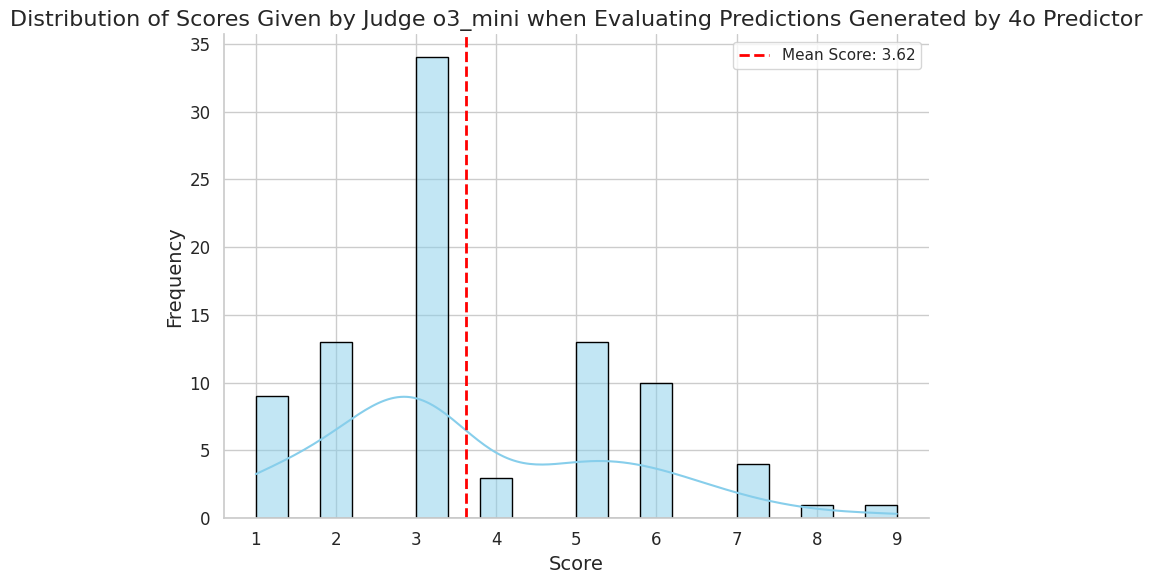

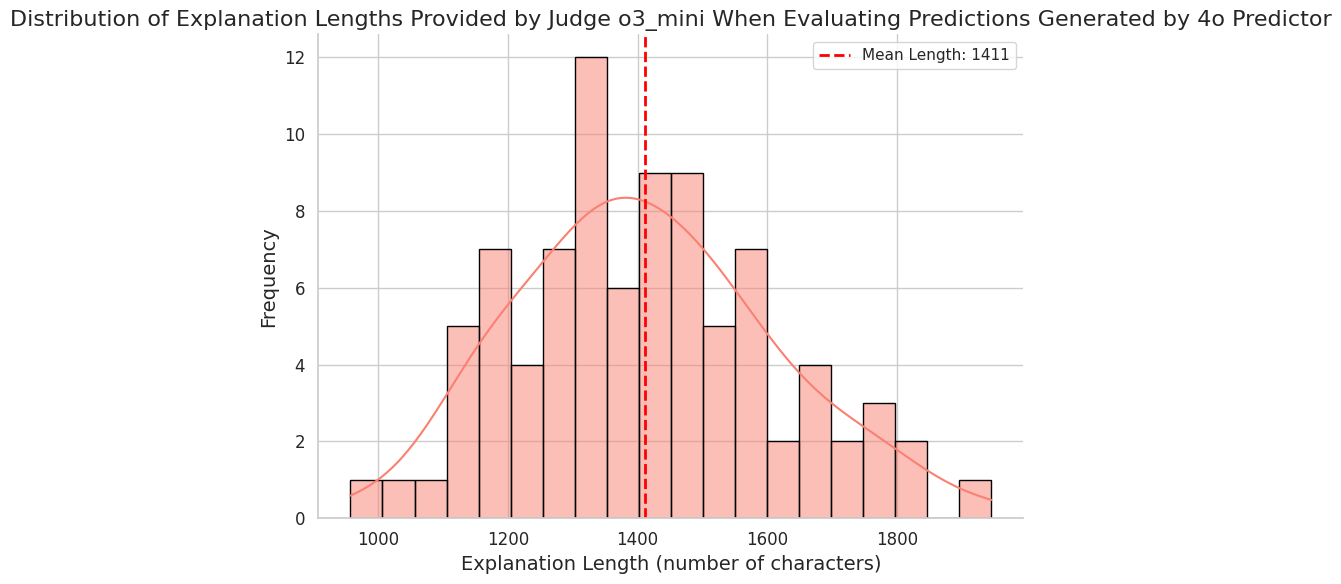

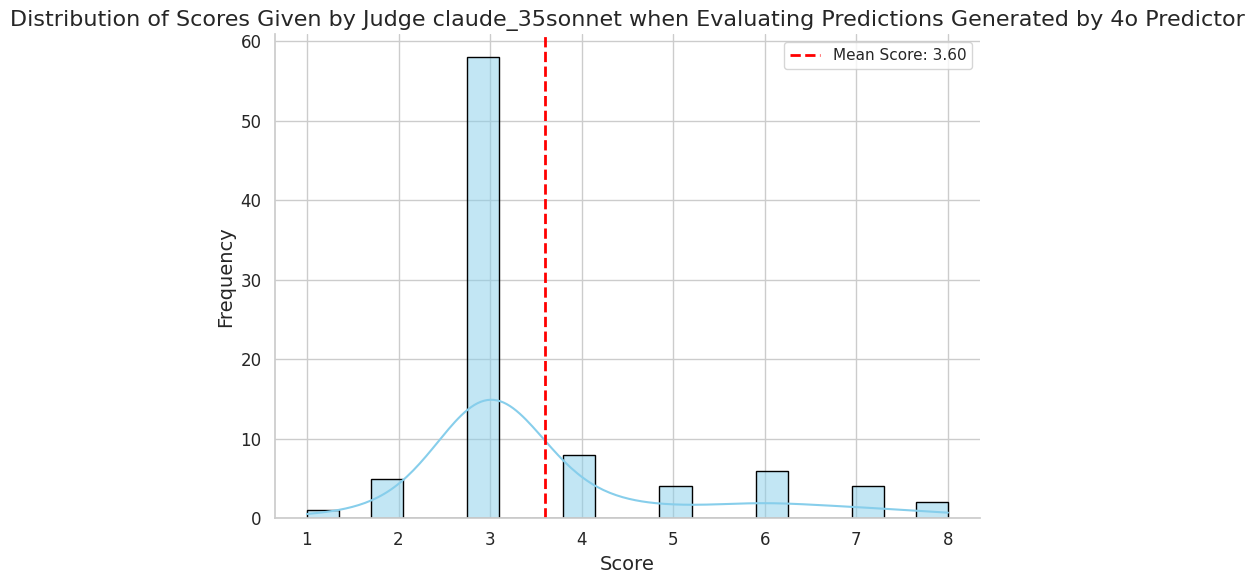

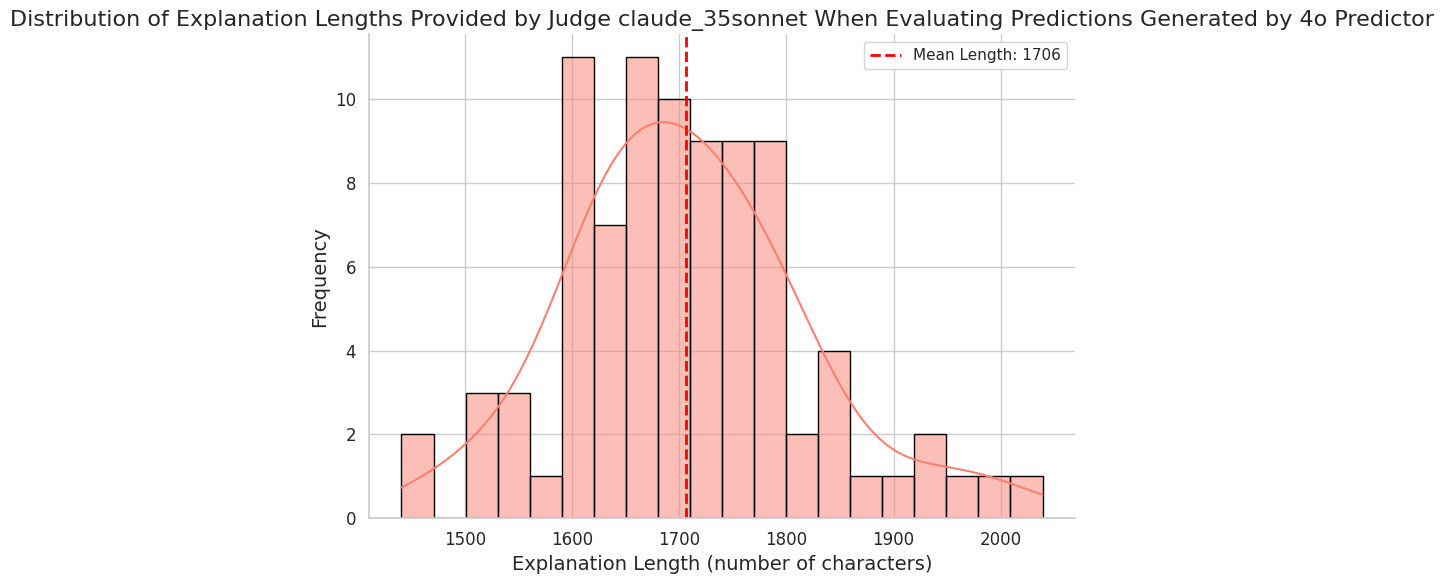

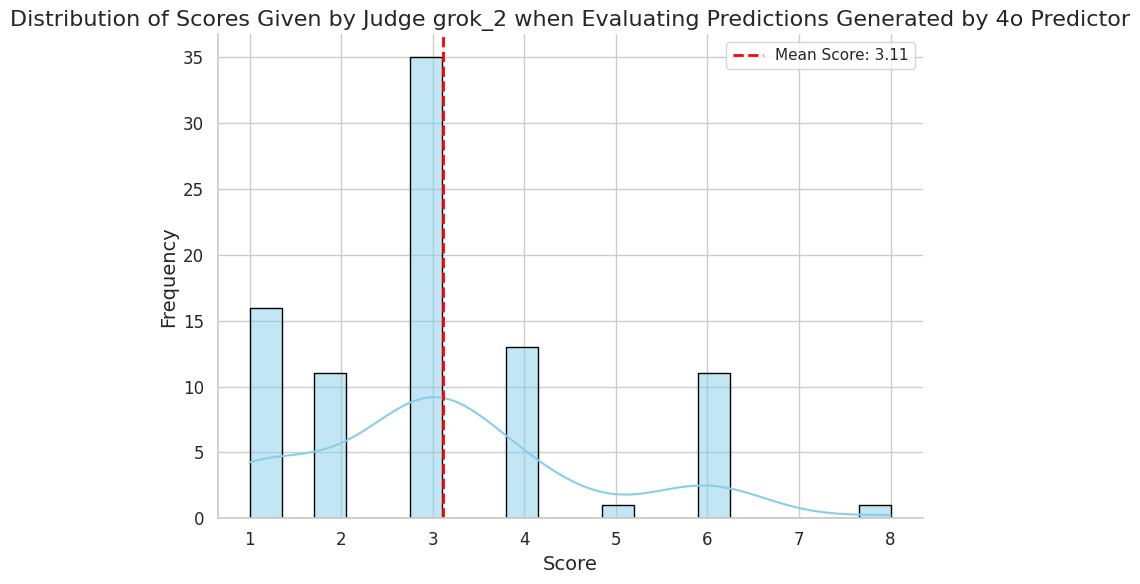

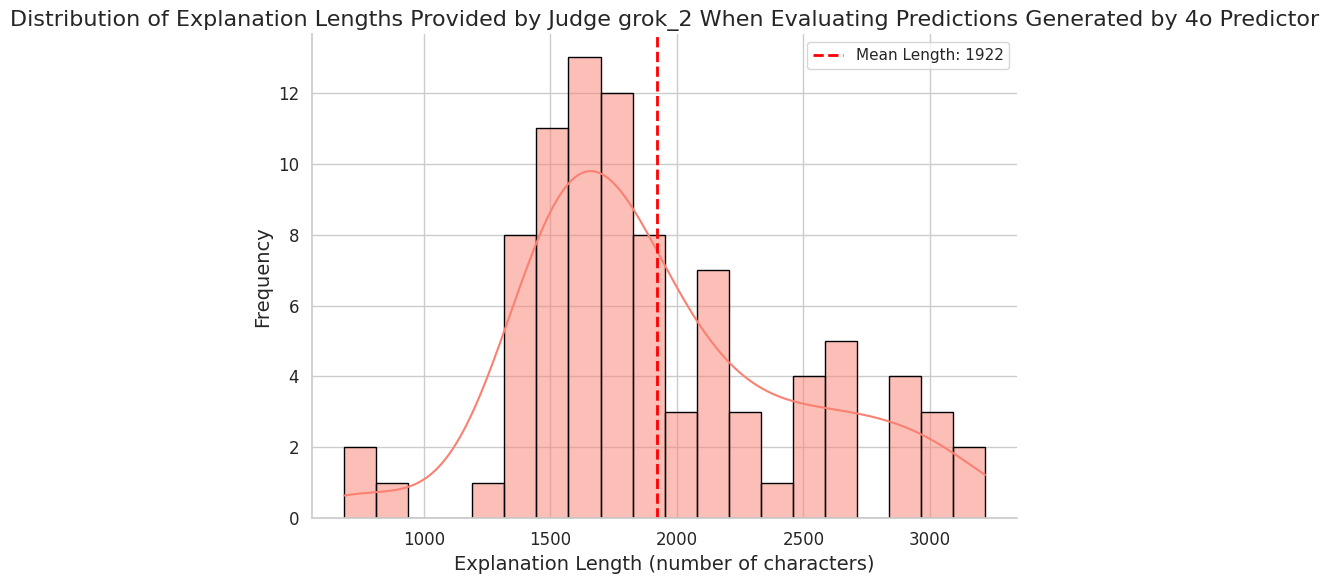

<ipython-input-4-7533d0ec4e2d>:168: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='model', y='score', data=df, palette="Set2")


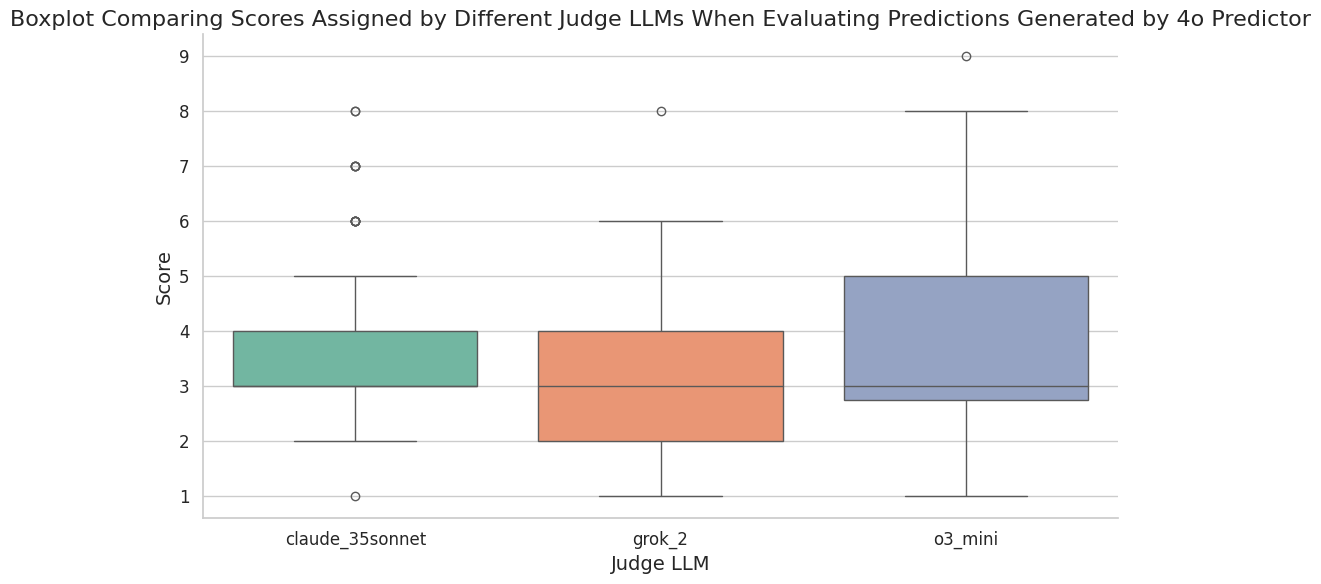

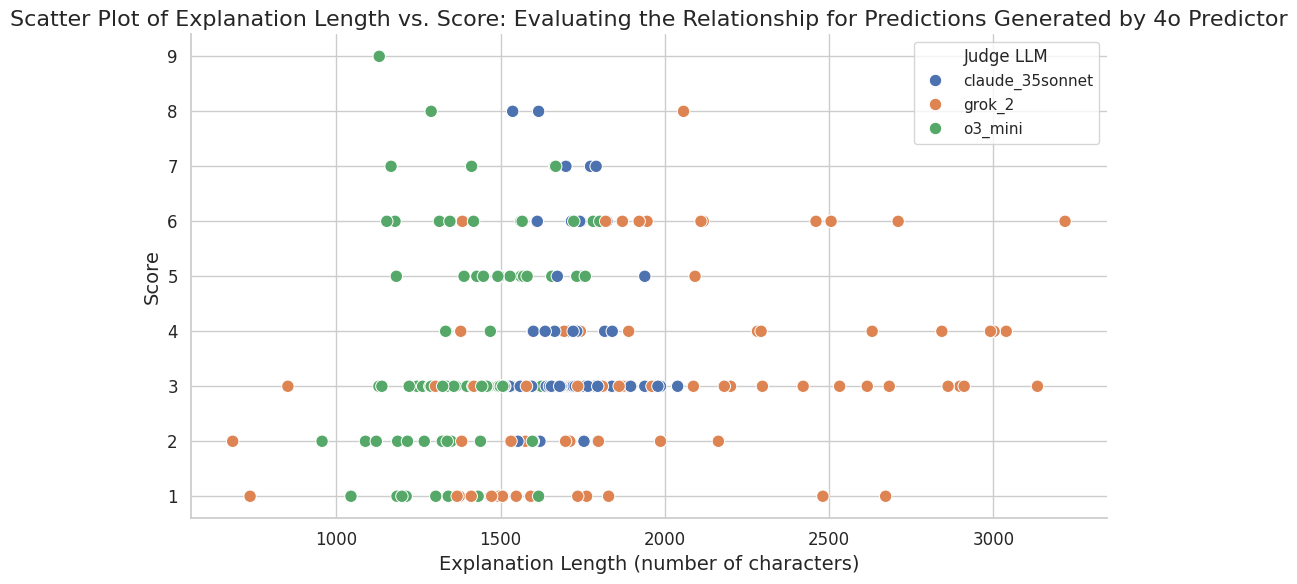

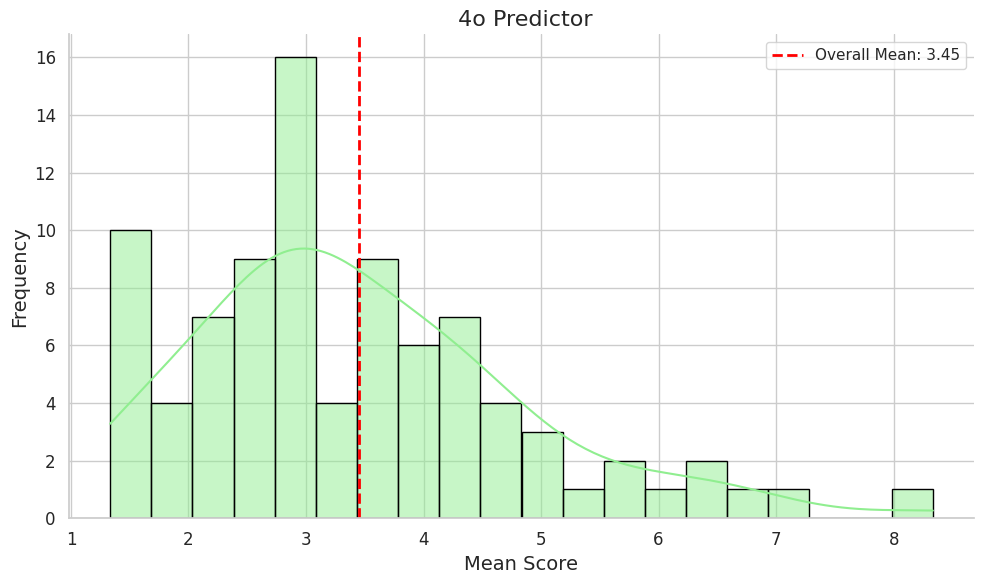

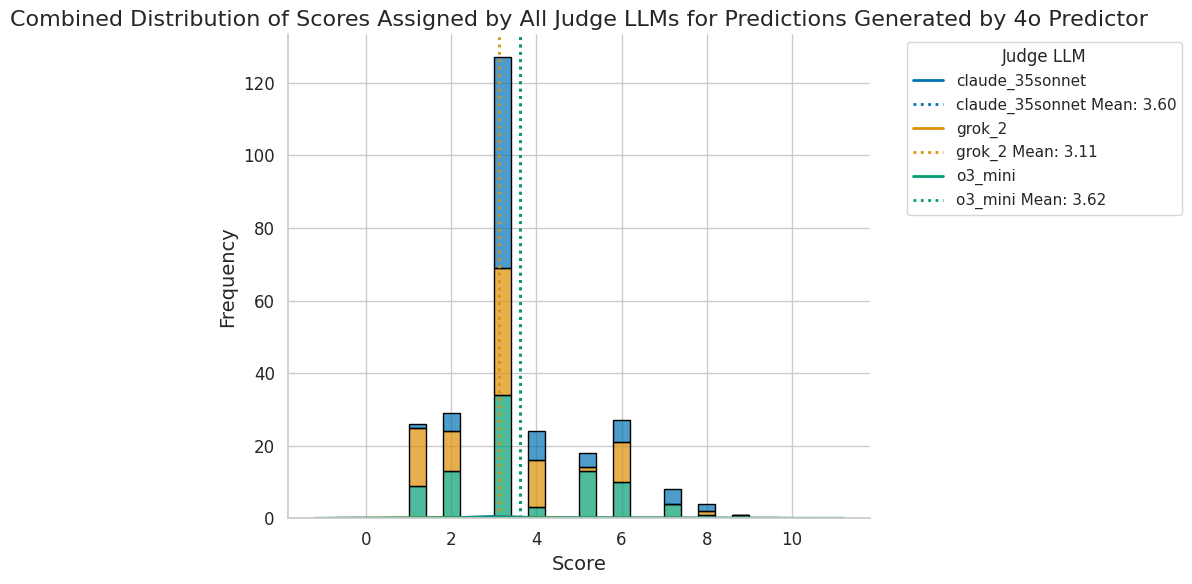

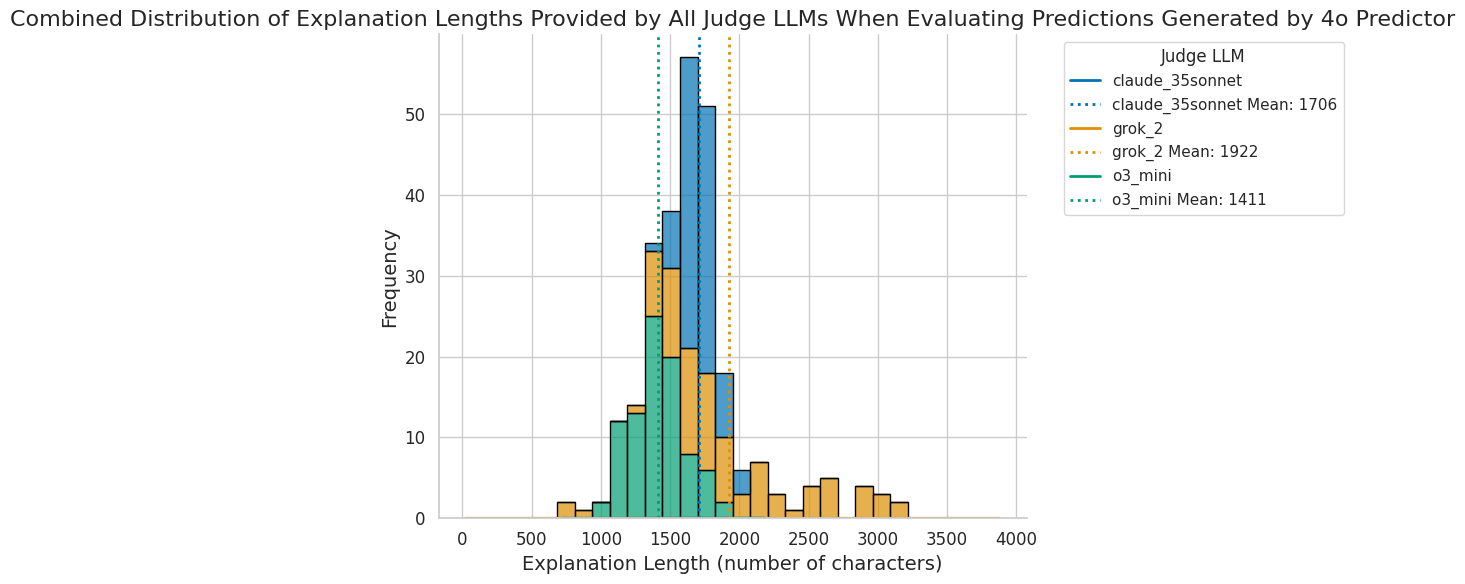

Finished processing base directory: 4o_judging

Processing base directory: claude_judging (excluding judge: claude_35sonnet)


100%|██████████| 132/132 [01:06<00:00,  1.99it/s]


Data loaded for 264 entries in claude_judging.
Mean scores saved to /content/drive/MyDrive/ResearchPapers/claude_judging/claude_judging_new_mean_scores.csv


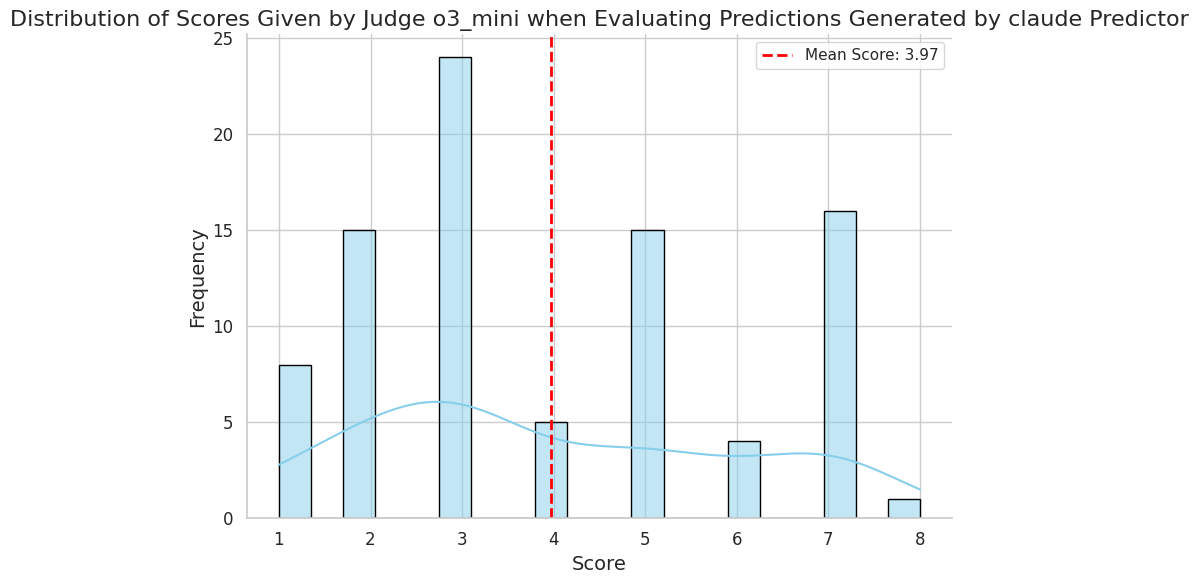

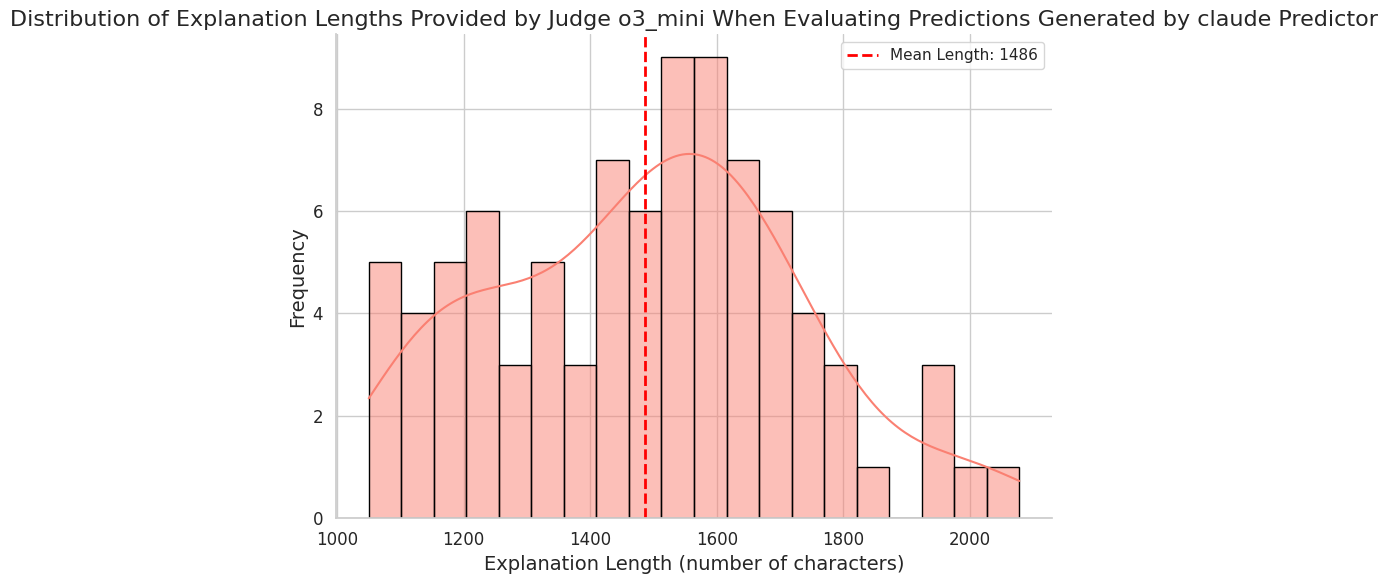

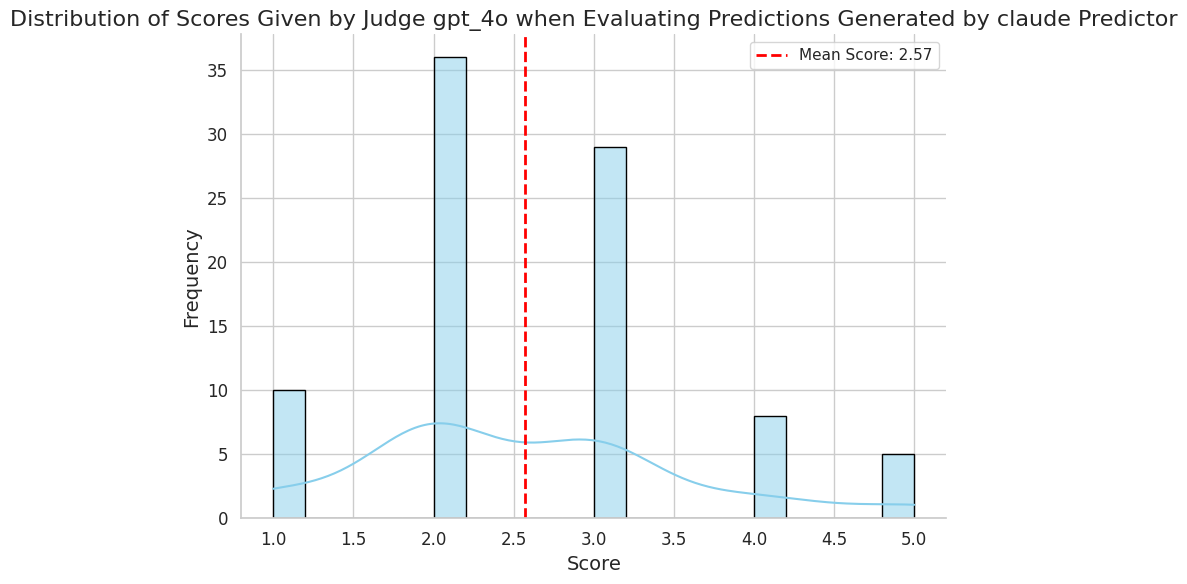

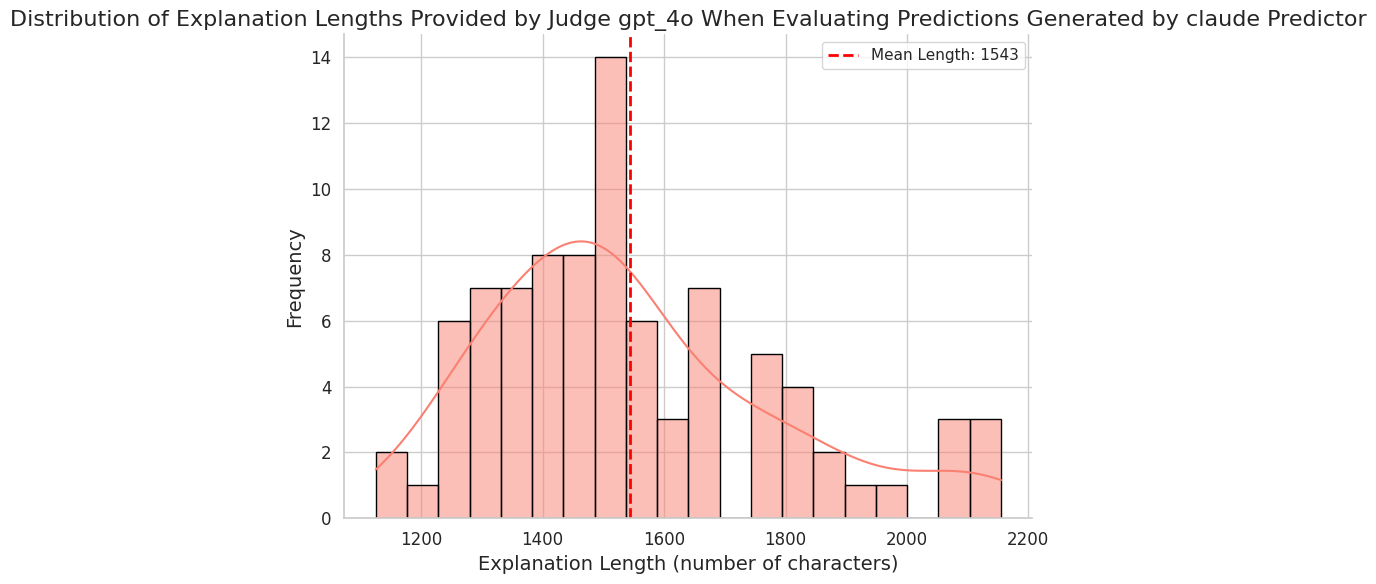

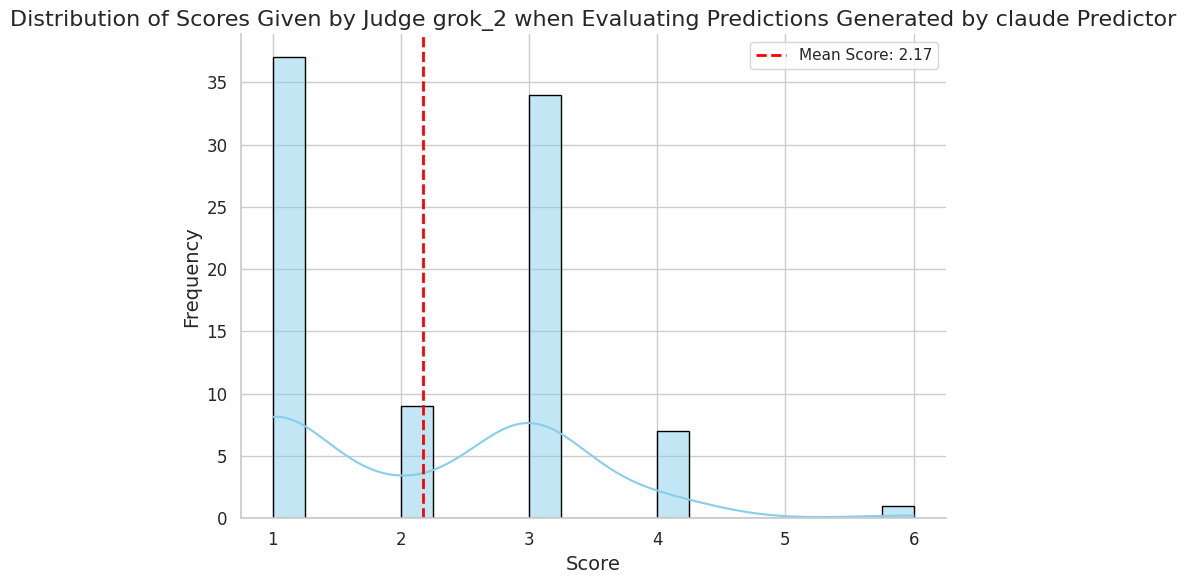

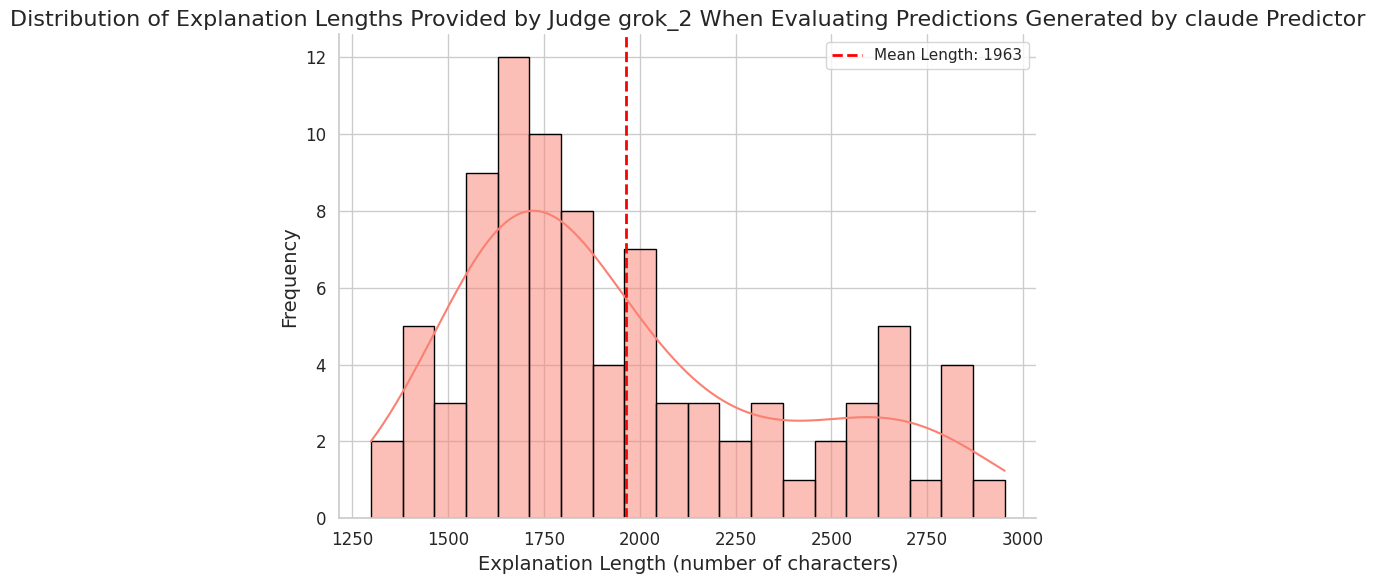

<ipython-input-4-7533d0ec4e2d>:168: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='model', y='score', data=df, palette="Set2")


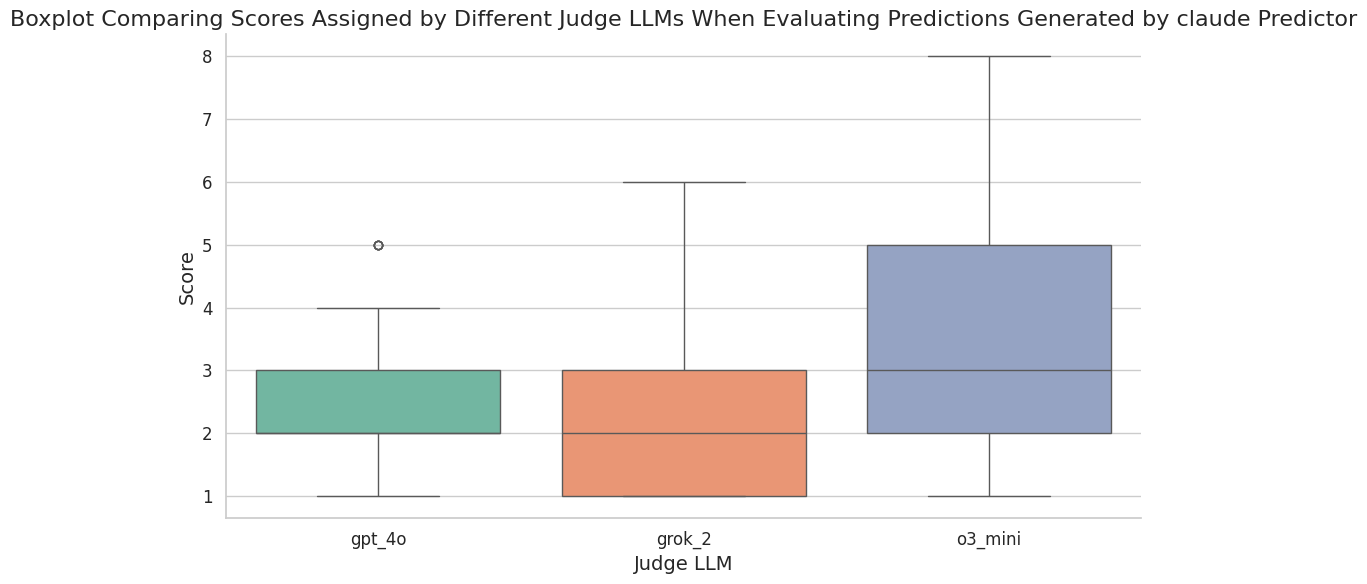

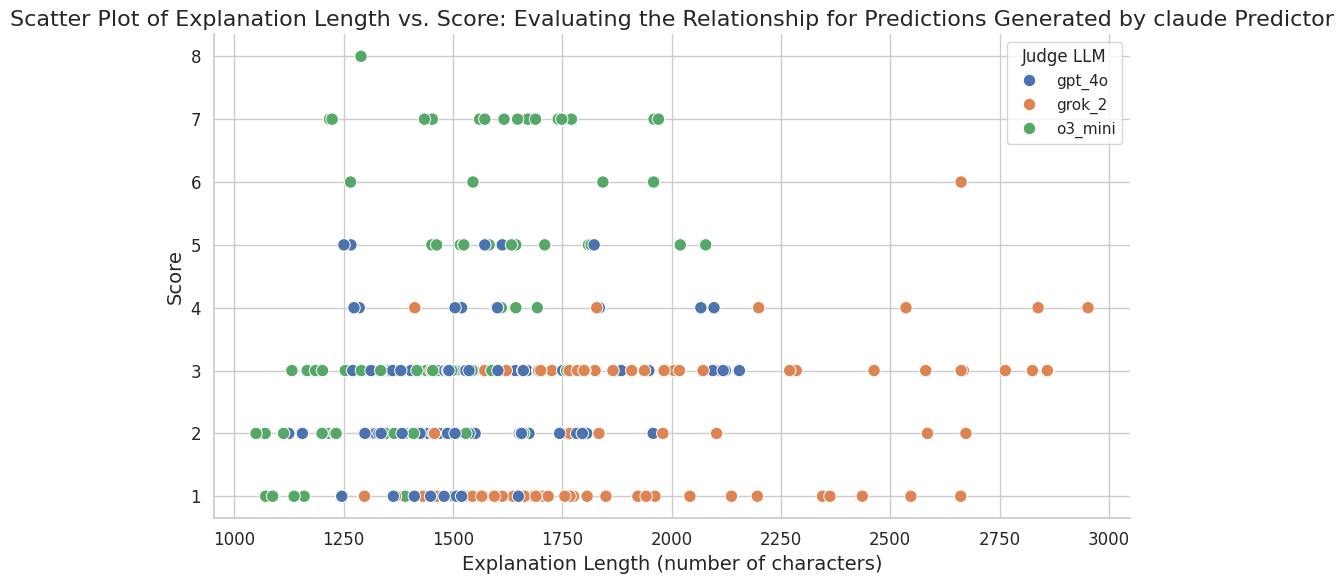

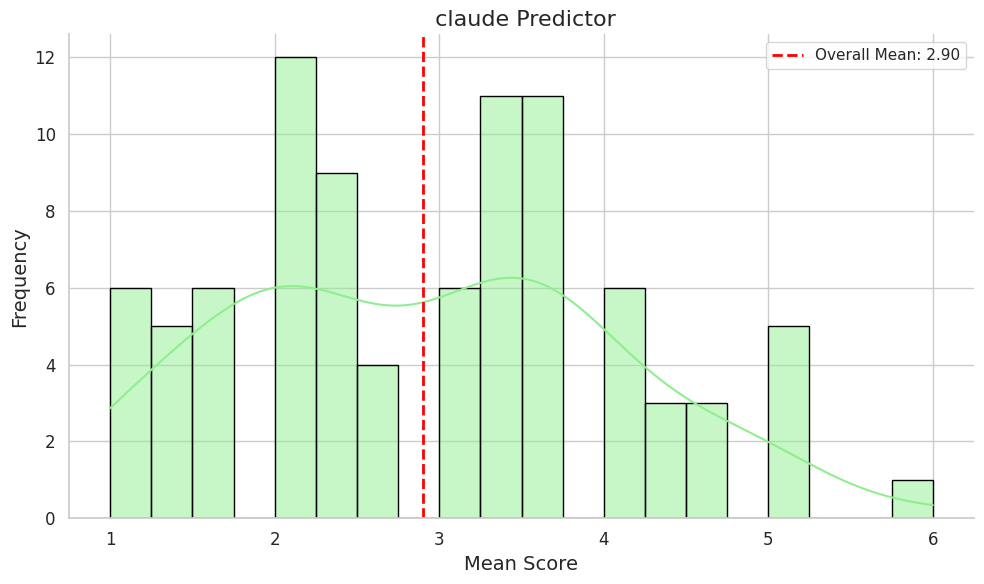

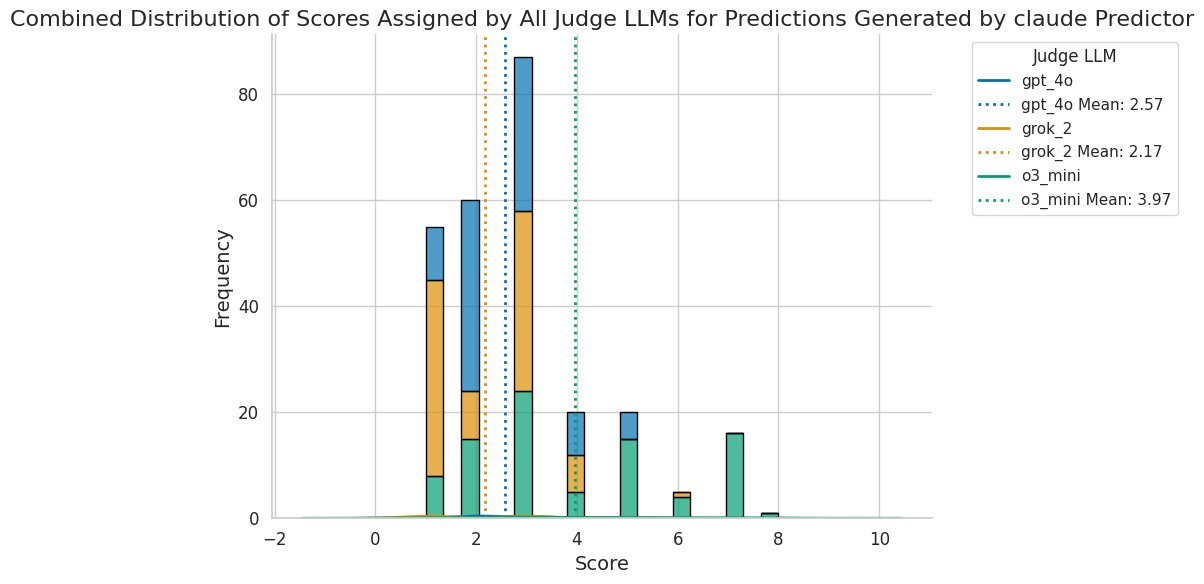

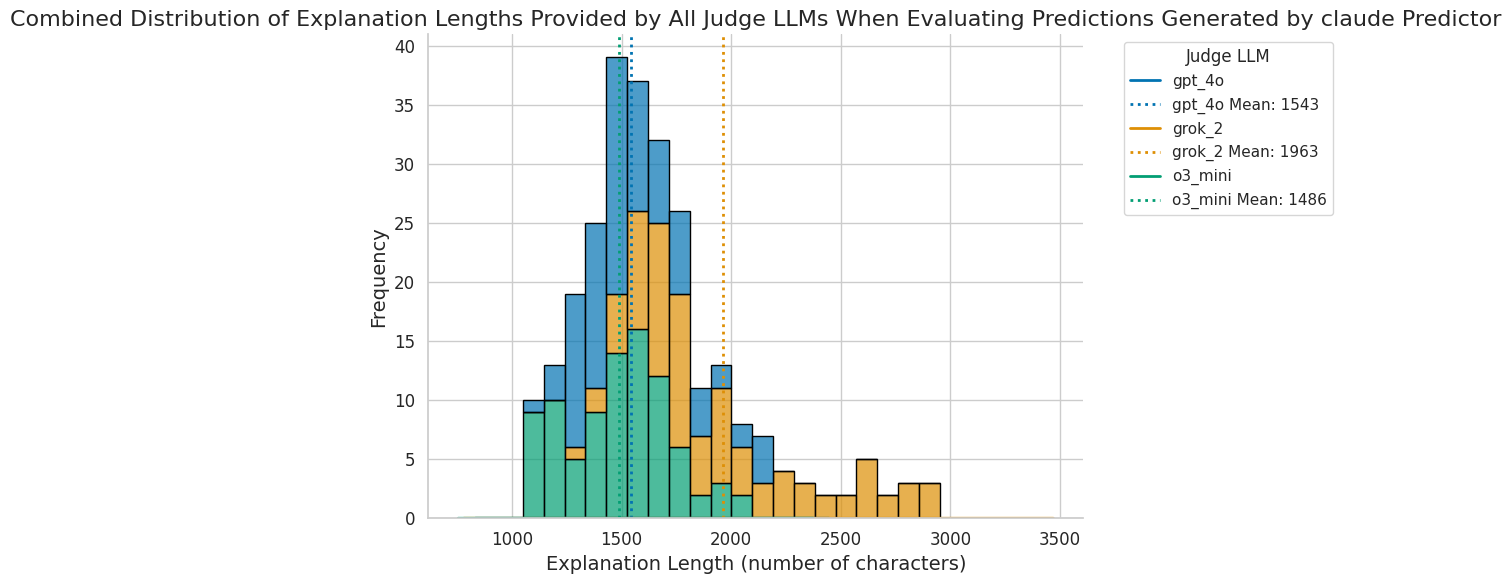

Finished processing base directory: claude_judging

Processing base directory: gemini_judging (excluding judge: gemini_15pro)


100%|██████████| 133/133 [01:21<00:00,  1.63it/s]


Data loaded for 352 entries in gemini_judging.
Mean scores saved to /content/drive/MyDrive/ResearchPapers/gemini_judging/gemini_judging_new_mean_scores.csv


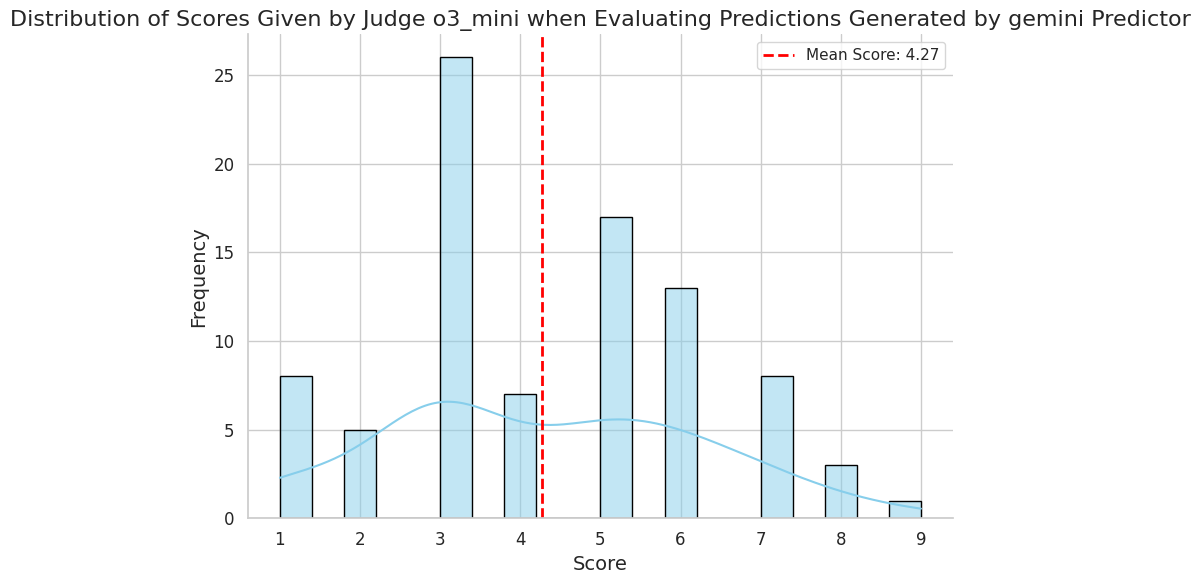

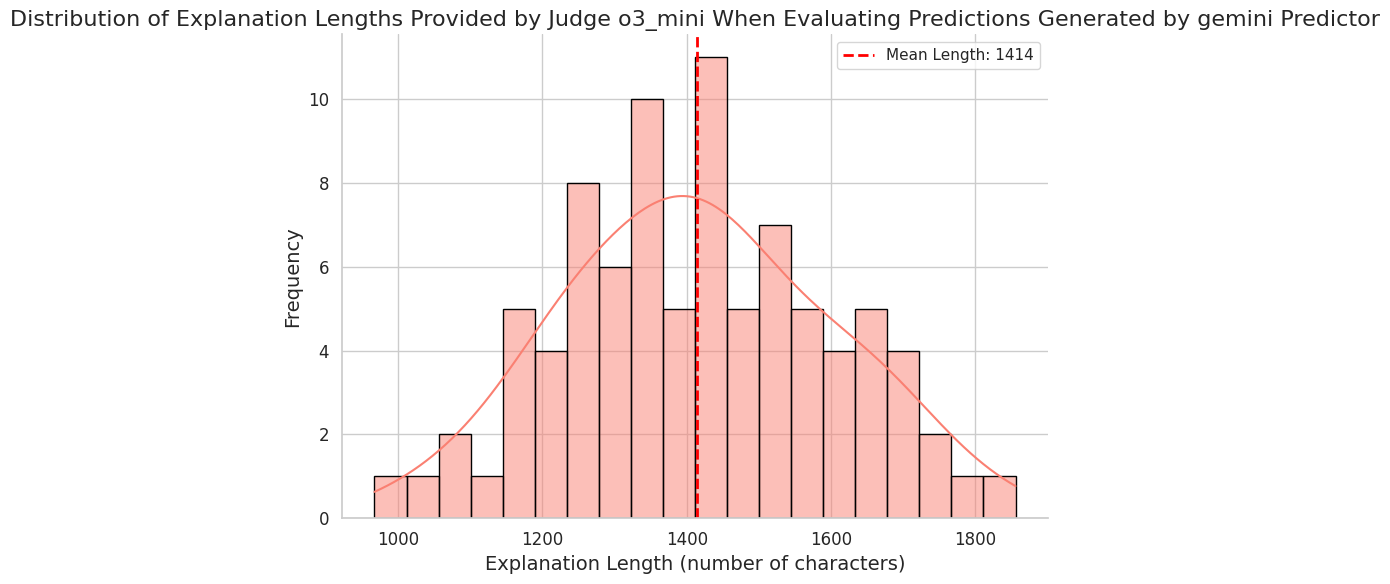

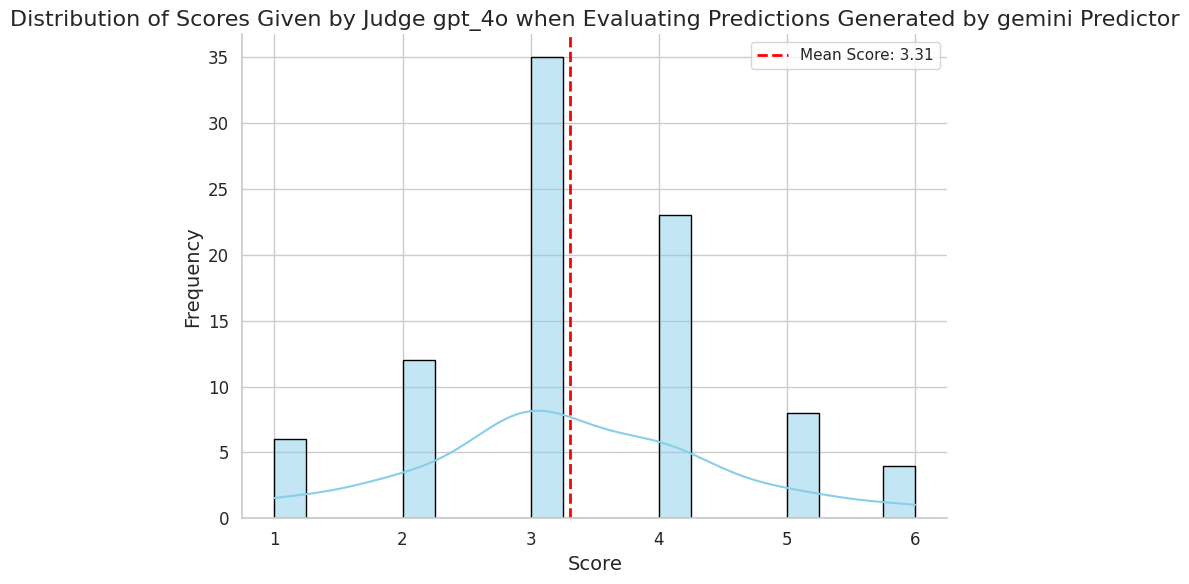

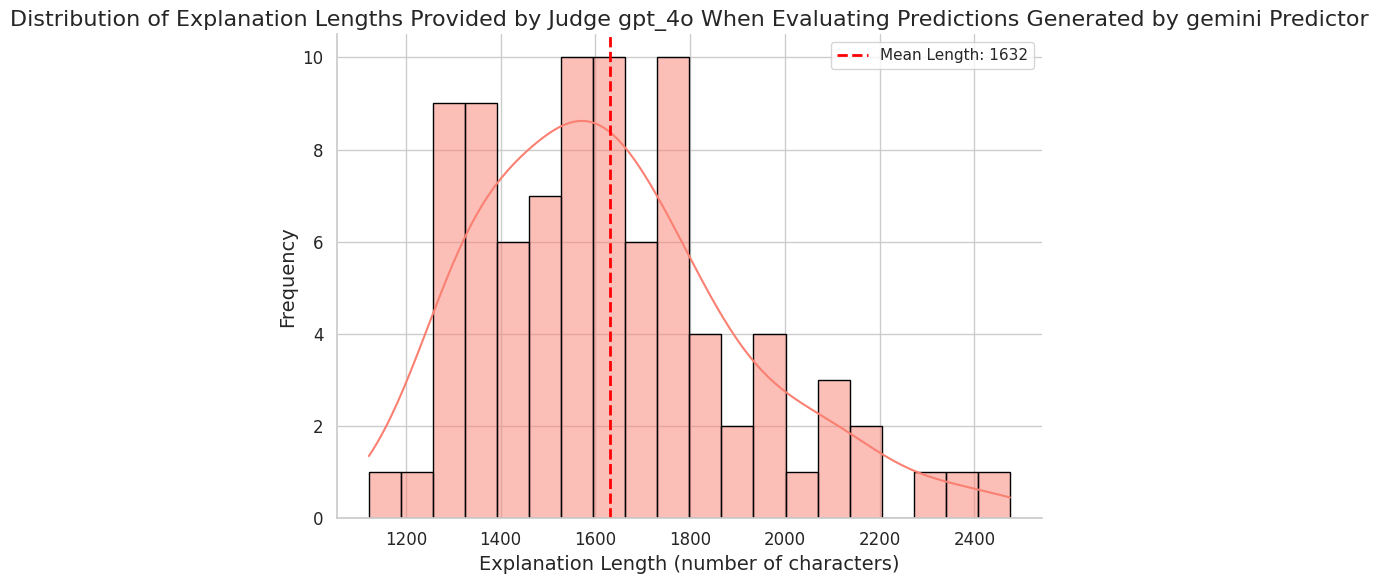

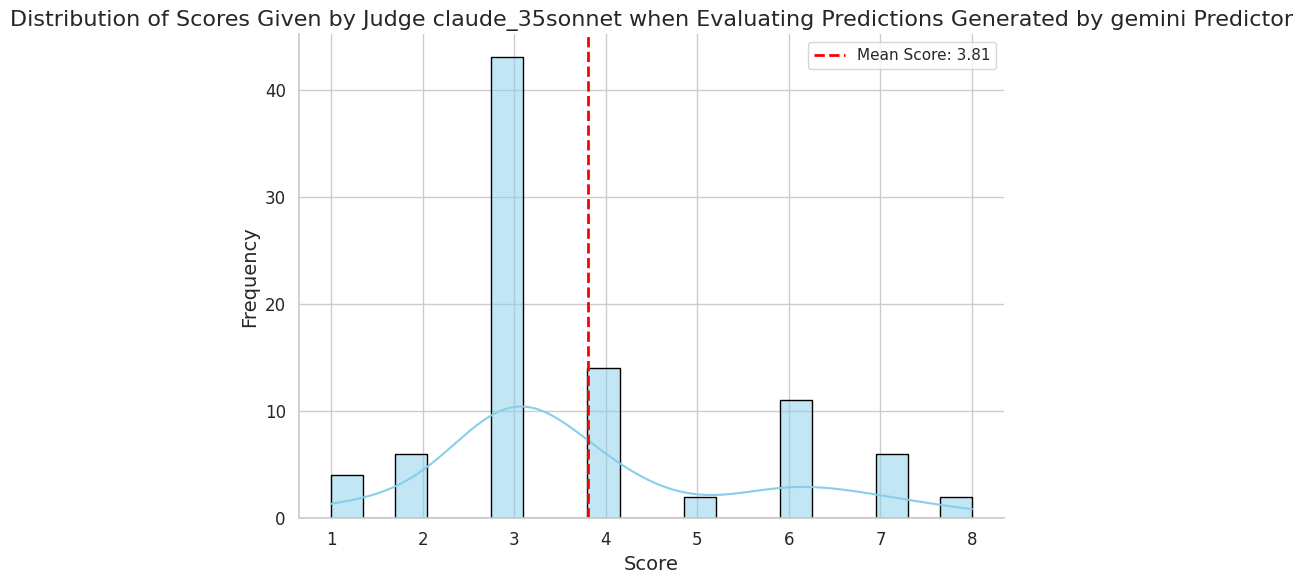

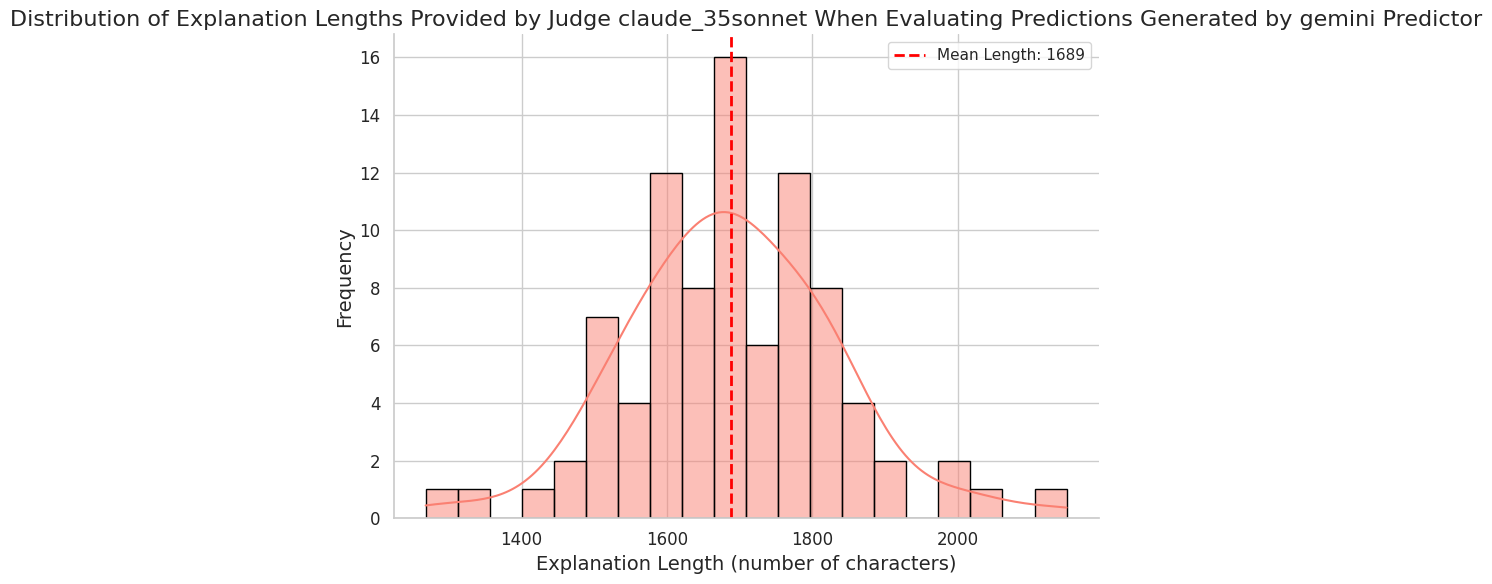

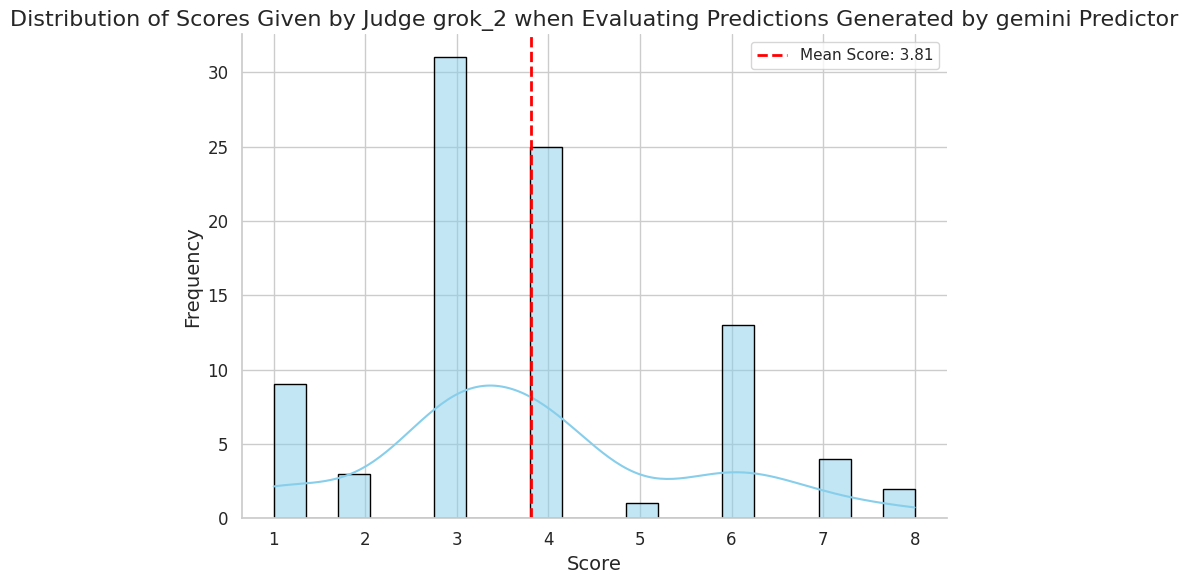

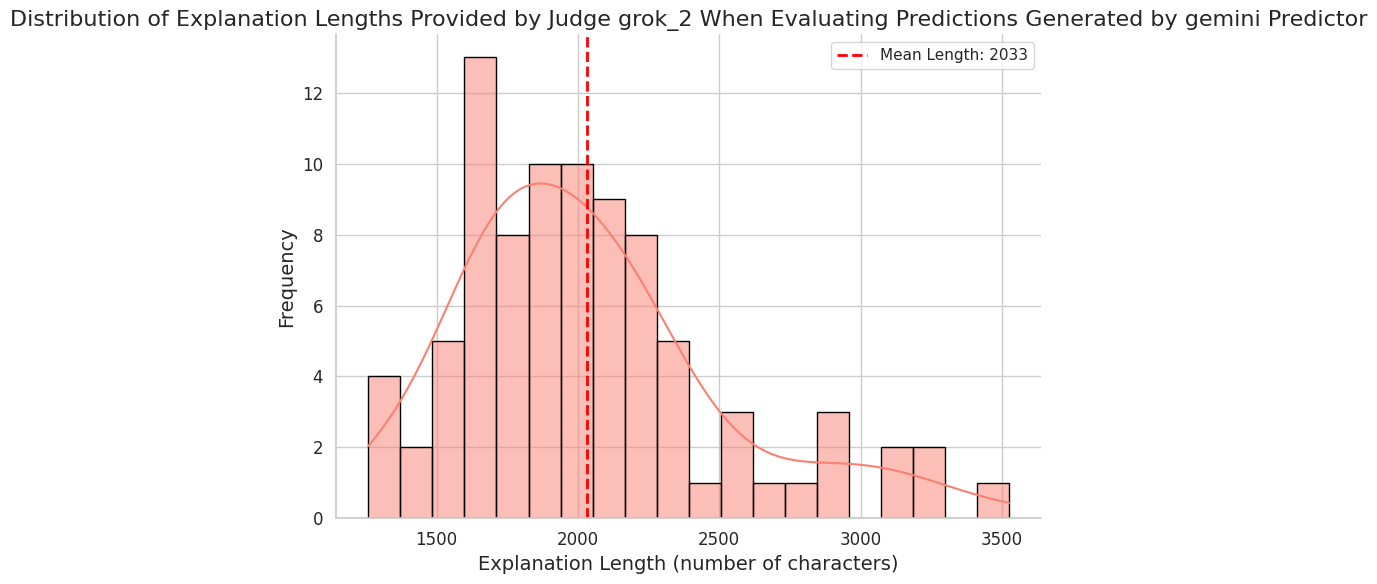

<ipython-input-4-7533d0ec4e2d>:168: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='model', y='score', data=df, palette="Set2")


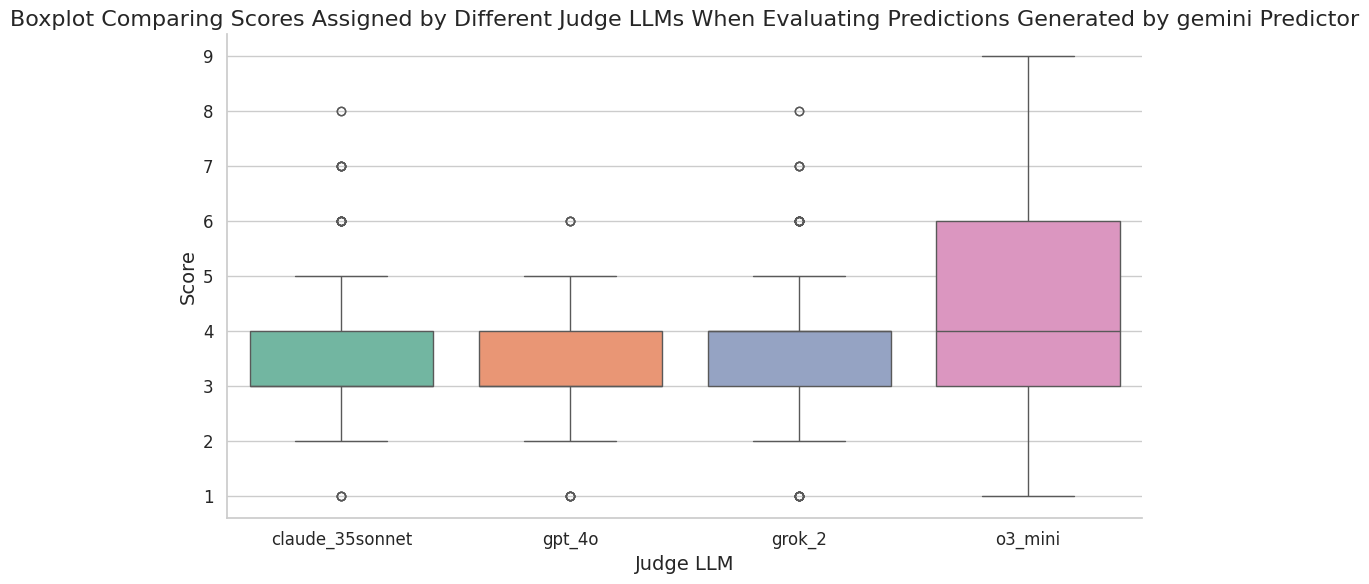

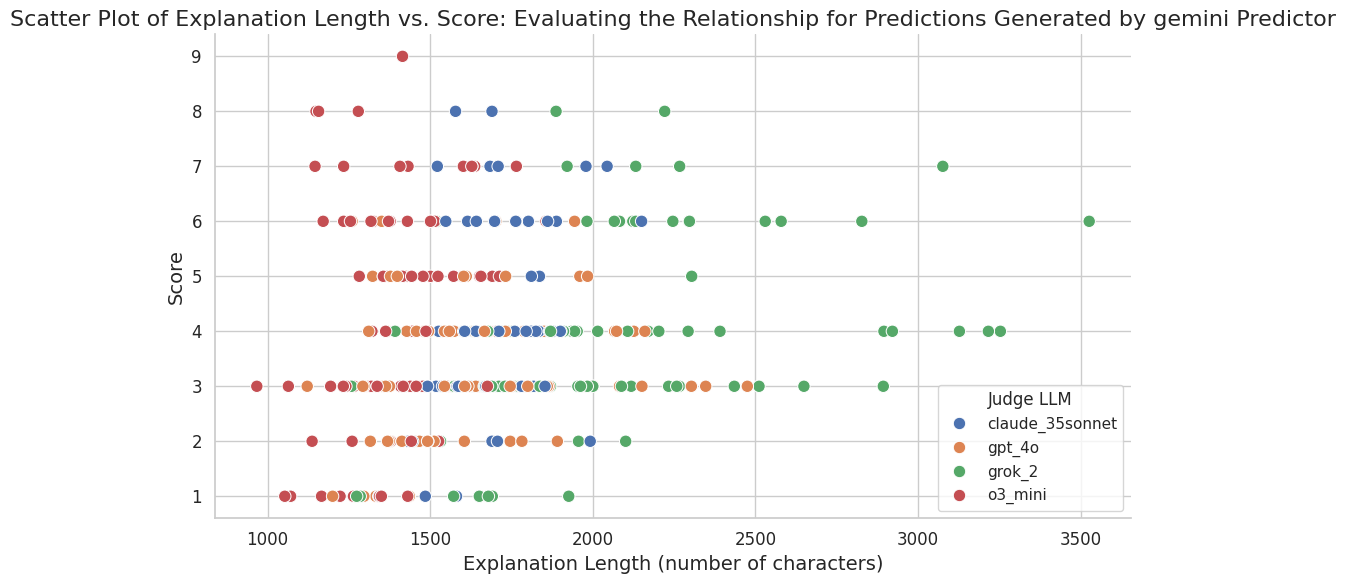

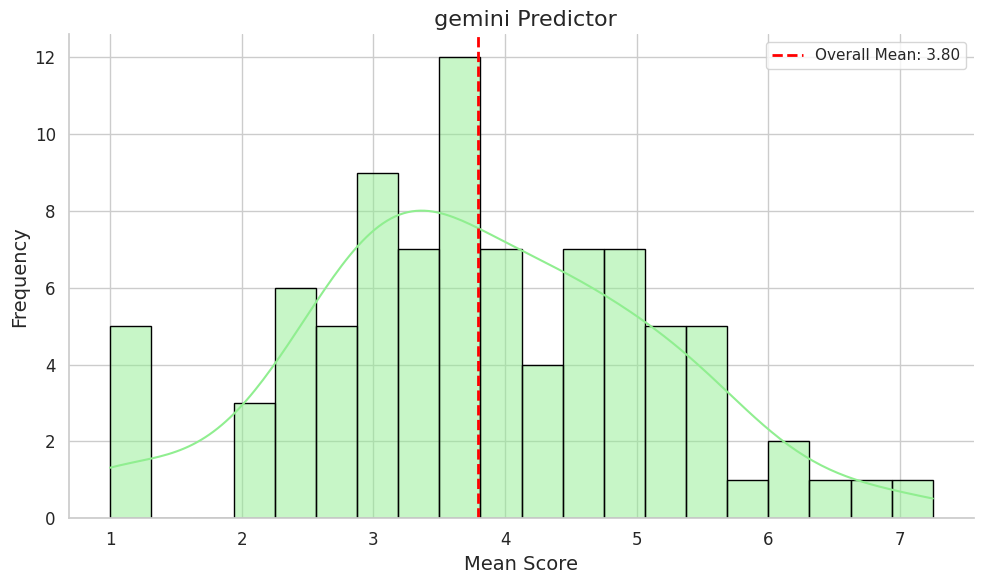

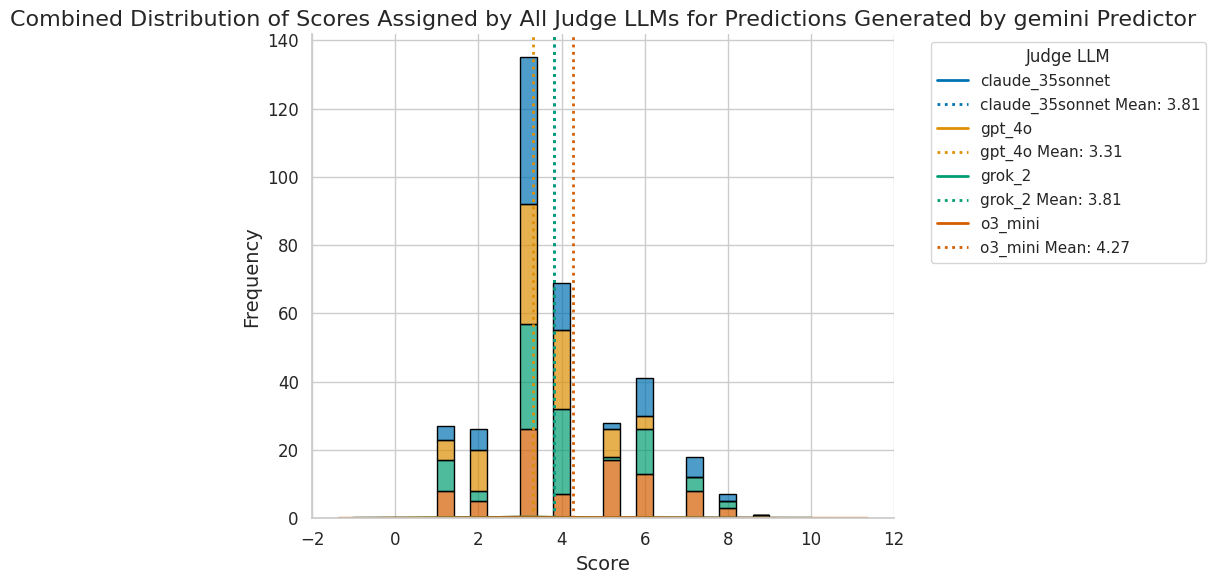

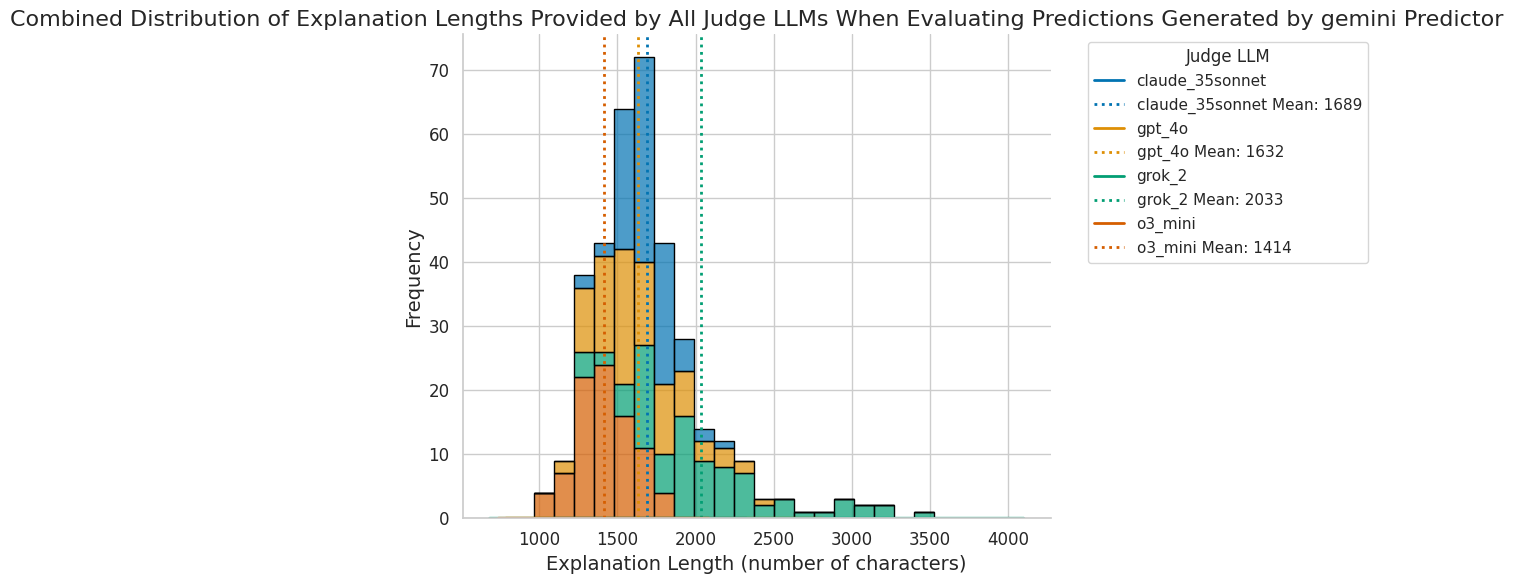

Finished processing base directory: gemini_judging

Processing base directory: o3mini_judging (excluding judge: o3_mini)


100%|██████████| 132/132 [00:55<00:00,  2.38it/s]


Data loaded for 264 entries in o3mini_judging.
Mean scores saved to /content/drive/MyDrive/ResearchPapers/o3mini_judging/o3mini_judging_new_mean_scores.csv


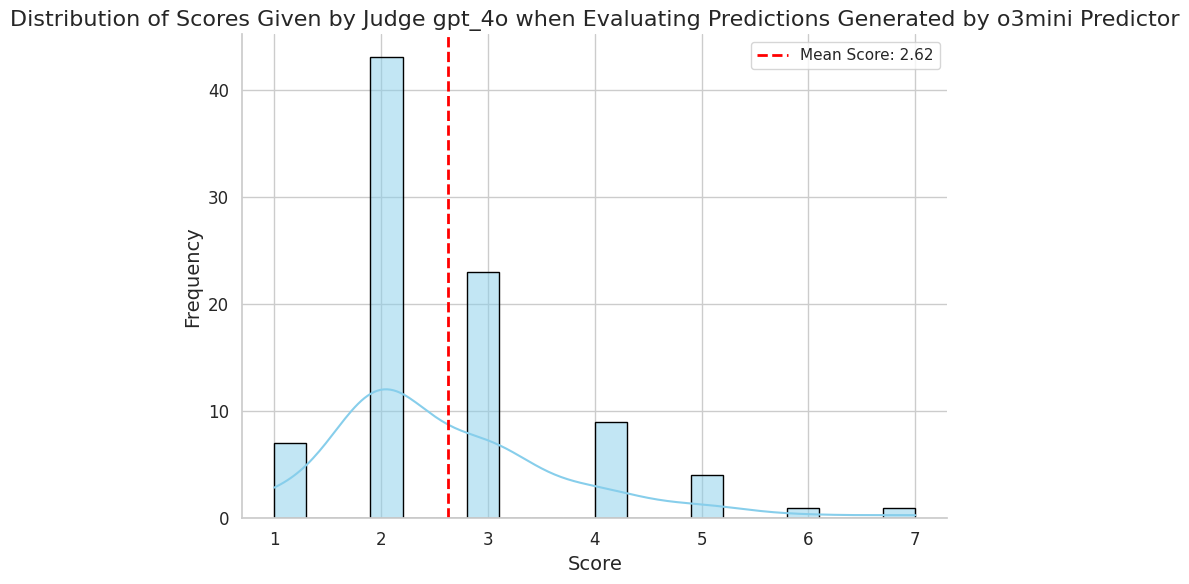

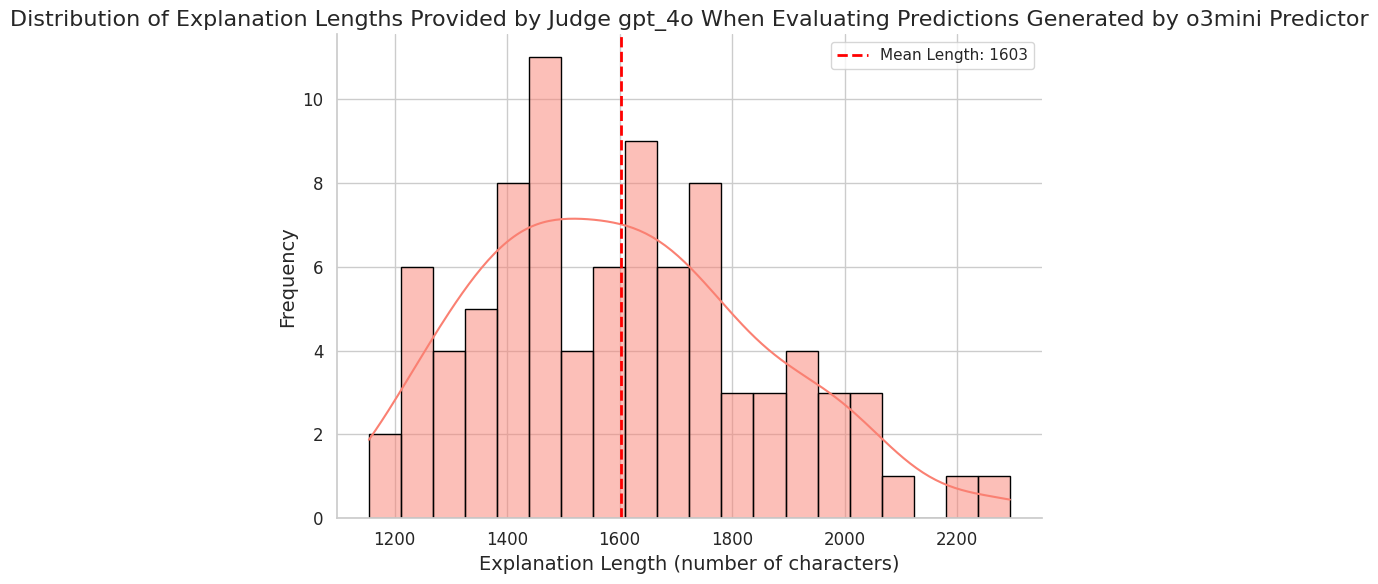

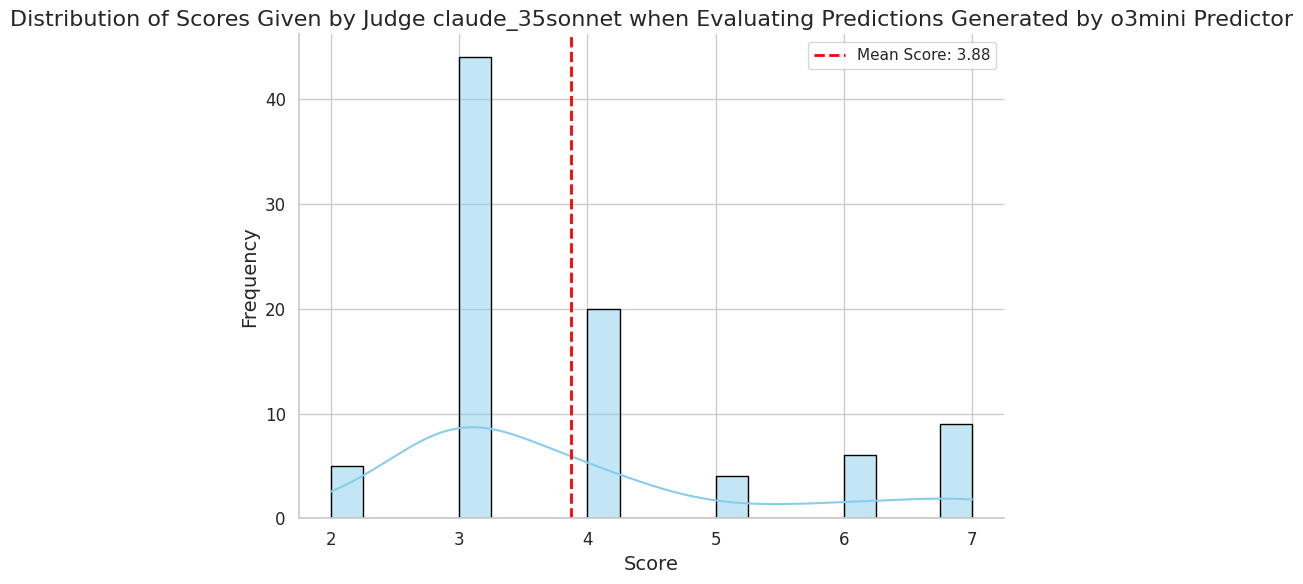

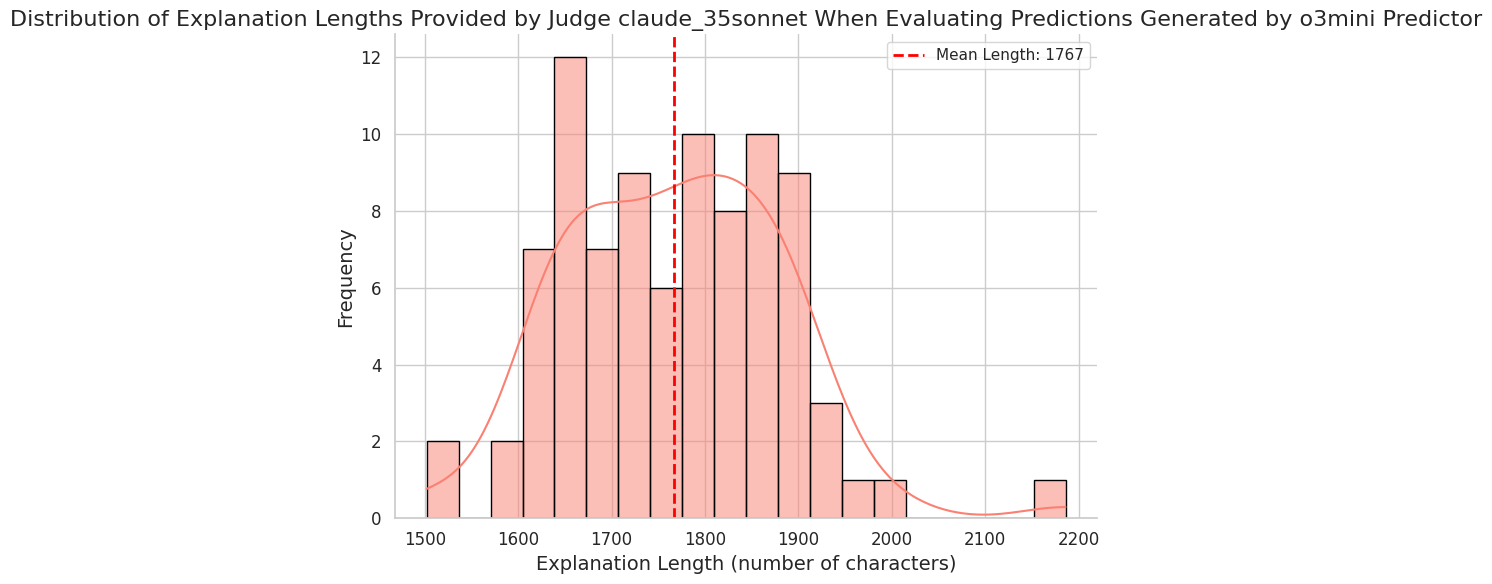

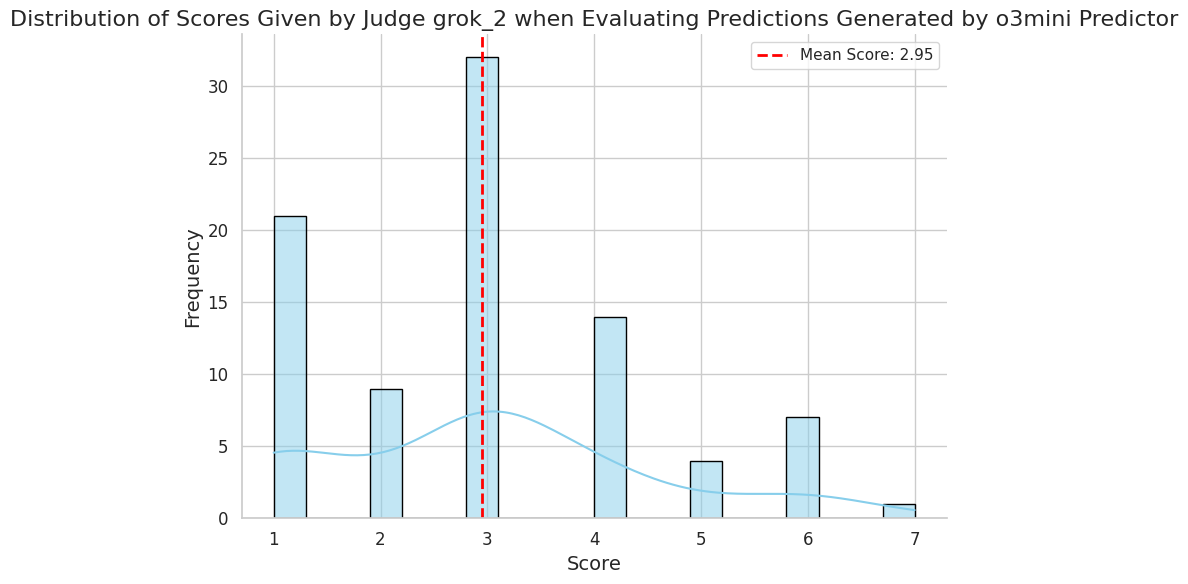

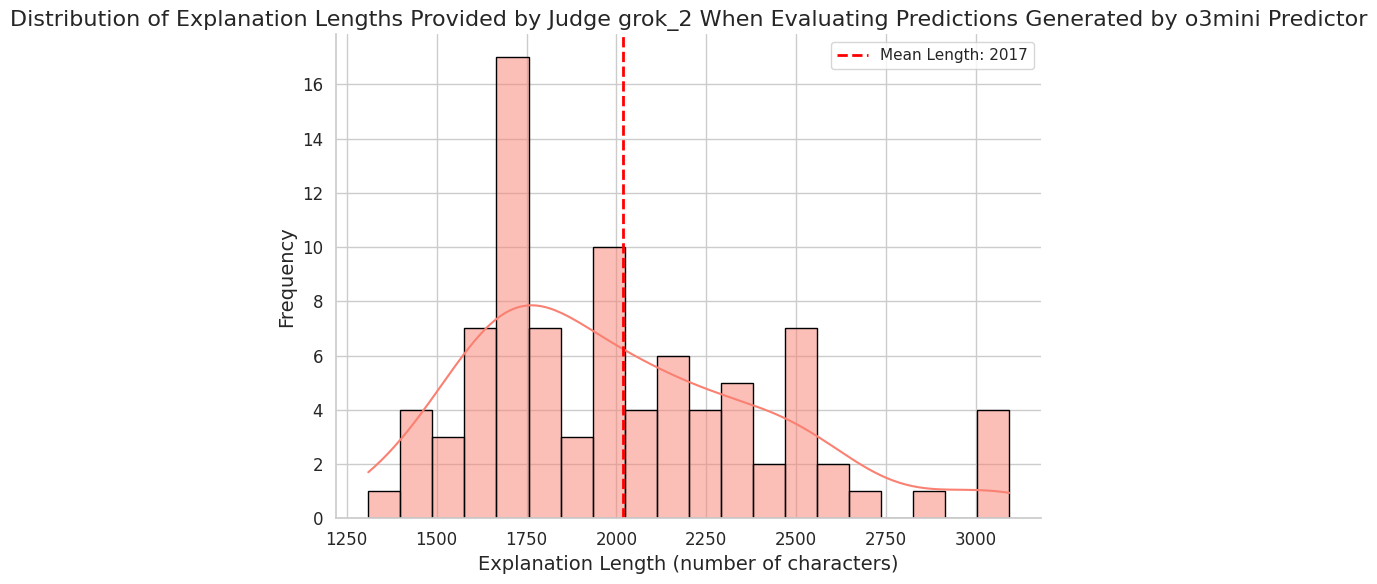

<ipython-input-4-7533d0ec4e2d>:168: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='model', y='score', data=df, palette="Set2")


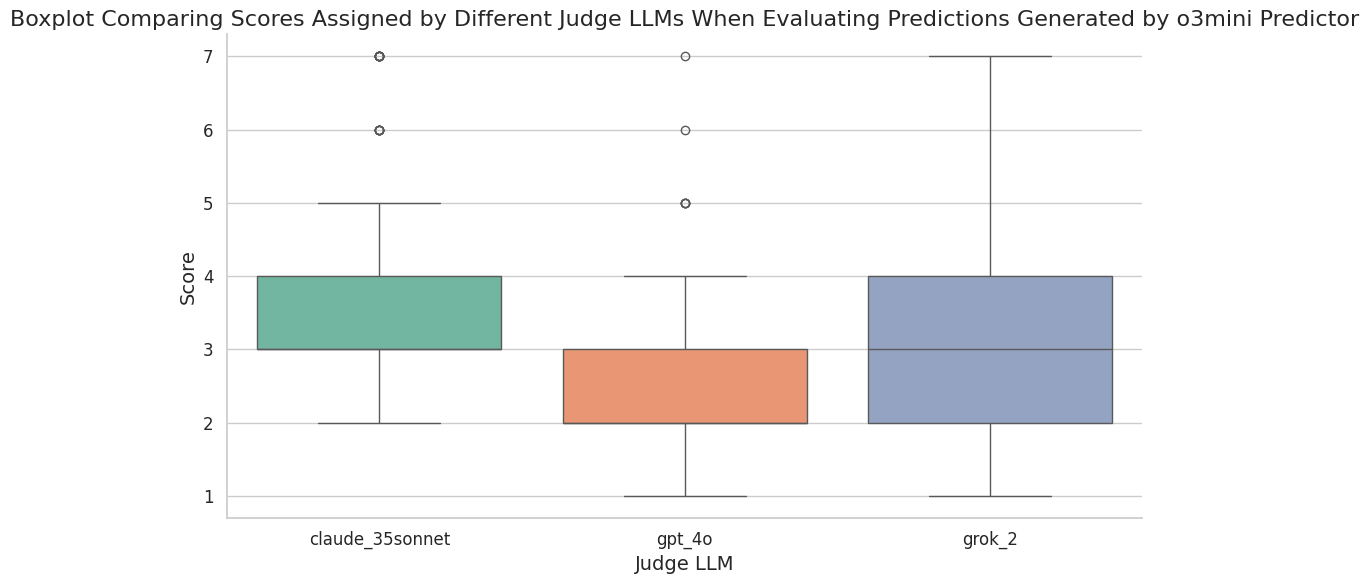

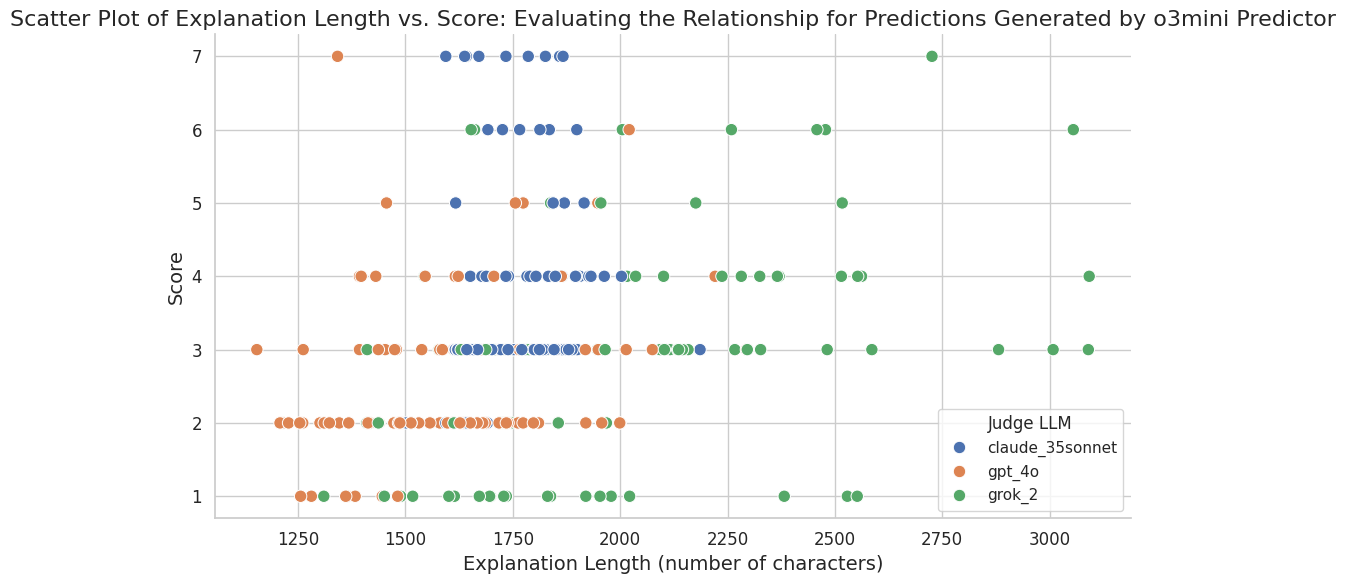

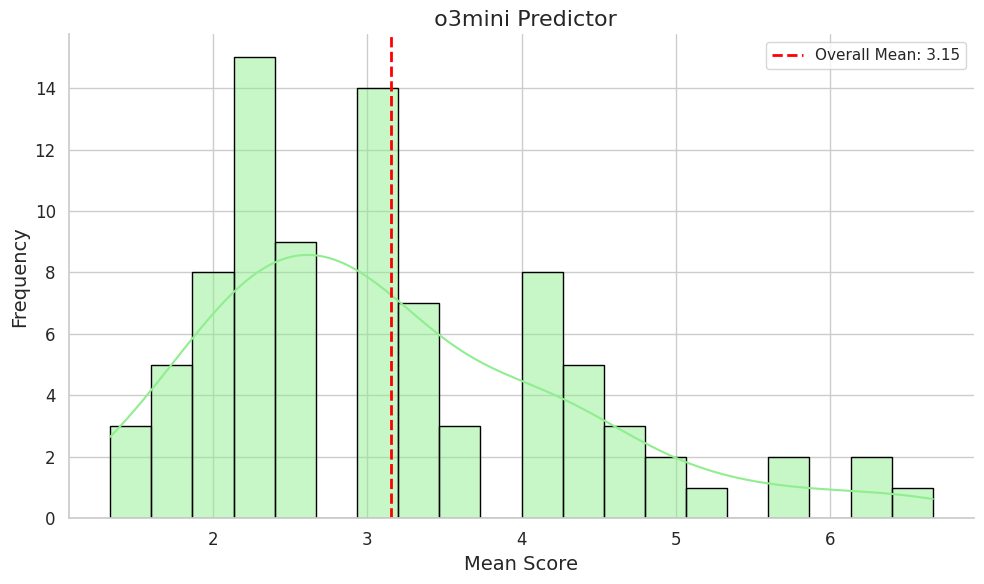

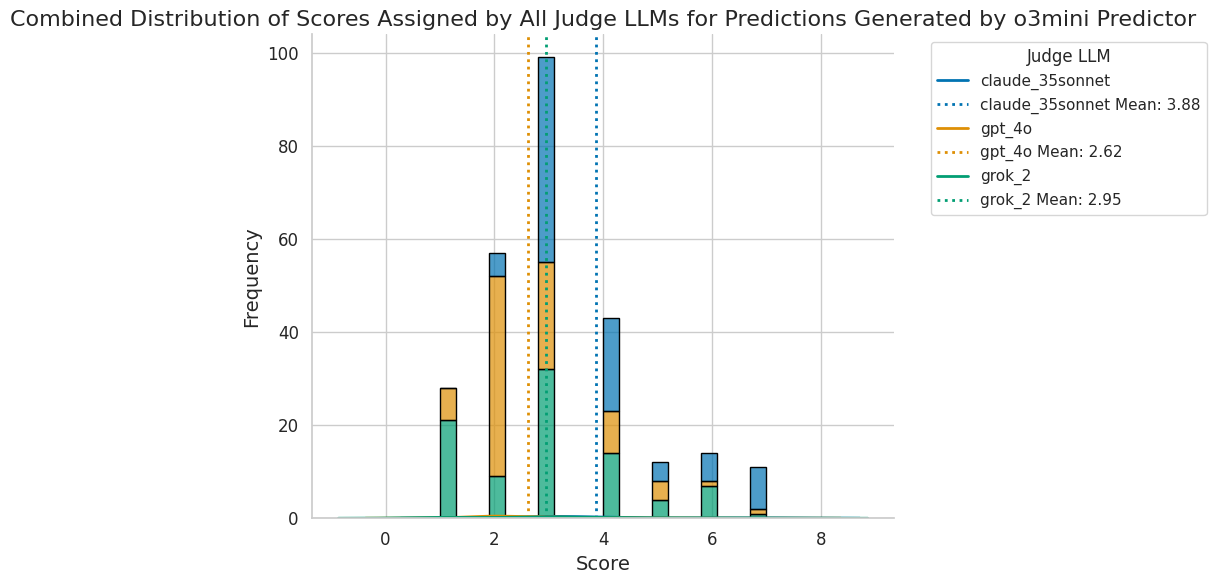

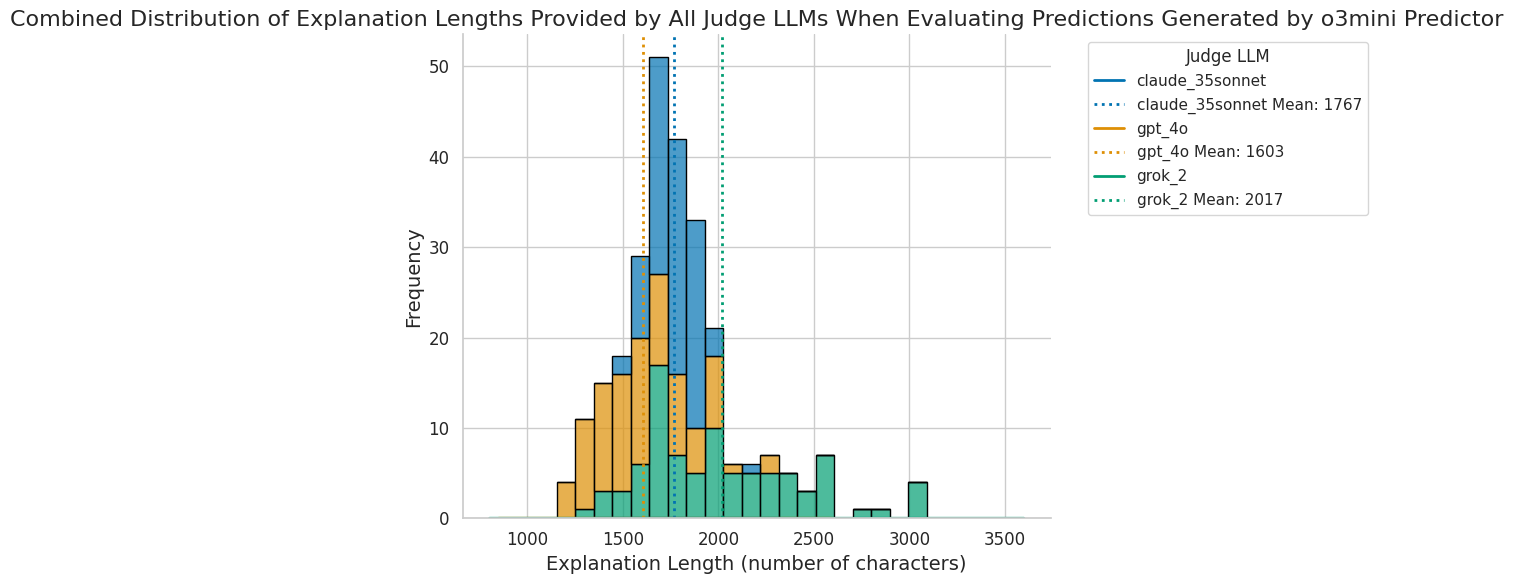

Finished processing base directory: o3mini_judging



In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

# -------------------------------
# Global Style Settings for Prettier Visuals
# -------------------------------
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    'figure.autolayout': True,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

# -------------------------------
# 1. Define Parent Directory and Allowed Judge Models
# -------------------------------
# Set this to the parent folder containing the base directories (e.g., "4o_judging", etc.)
ROOT_DIR = '/content/drive/MyDrive/ResearchPapers'

# The allowed judge models (across all base directories)
allowed_judges = {"claude_35sonnet", "gpt_4o", "grok_2", "o3_mini", }  # "gemini_15pro" is commented out

# Mapping from base directory key to the judge model that should be excluded.
# For example, in "4o_judging", we want to exclude "gpt_4o".
base_exclude_map = {
    "4o": "gpt_4o",
    "claude": "claude_35sonnet",
    "gemini": "gemini_15pro",
    "o3mini": "o3_mini"
}

to_remove = ["paper_000", "paper_001", "paper_003", "paper_025", "paper_029", "paper_036", "paper_043", "paper_050", "paper_055", "paper_060", "paper_076", "paper_081", "paper_097"]

# -------------------------------
# 2. Process Each Base Directory
# -------------------------------
for base_dir in sorted(os.listdir(ROOT_DIR)):
    if not base_dir.endswith("_judging"):
        continue

    base_dir_path = os.path.join(ROOT_DIR, base_dir)
    if not os.path.isdir(base_dir_path):
        continue

    # Determine the base key (e.g., "4o" from "4o_judging")
    base_key = base_dir.replace("_judging", "")
    # Find the judge model to exclude for this base directory
    exclude_model = base_exclude_map.get(base_key, None)
    # Allowed judge models for this base = all allowed judges minus the excluded one
    allowed_for_this_base = allowed_judges.copy()
    if exclude_model and exclude_model in allowed_for_this_base:
        allowed_for_this_base.remove(exclude_model)

    print(f"Processing base directory: {base_dir} (excluding judge: {exclude_model})")

    records = []
    # Loop over each paper folder in the base directory (e.g., paper000, paper001, …)
    for paper in tqdm(sorted(os.listdir(base_dir_path))):

        # skip removed papers
        if paper in to_remove:
            continue

        paper_dir = os.path.join(base_dir_path, paper)
        if not os.path.isdir(paper_dir):
            continue
        # Loop over each judging file in the paper folder
        for file in sorted(os.listdir(paper_dir)):
            if file.endswith('_majority_judge.txt'):
                # Get the judge model from the filename
                model = file.replace('_majority_judge.txt', '')
                # Skip if this model is not among the allowed ones for this base
                if model not in allowed_for_this_base:
                    continue
                file_path = os.path.join(paper_dir, file)
                with open(file_path, 'r') as f:
                    try:
                        data = json.load(f)
                    except json.JSONDecodeError:
                        print(f"Error decoding JSON in file: {file_path}")
                        continue

                score = data.get('score')
                explanation = data.get('explanation', '')
                explanation_length = len(explanation)
                records.append({
                    'paper': paper,
                    'model': model,
                    'score': score,
                    'explanation': explanation,
                    'explanation_length': explanation_length
                })

    # Convert the list of records to a DataFrame
    df = pd.DataFrame(records)
    print(f"Data loaded for {len(df)} entries in {base_dir}.")

    # -------------------------------
    # 3. Create Mean Scores CSV
    # -------------------------------
    # Pivot the DataFrame so each paper is one row with judge models as columns
    df_scores = df.pivot(index='paper', columns='model', values='score').reset_index()

    # Compute the mean score as the simple average of the allowed judge responses
    def compute_mean(row):
        vals = []
        for model in allowed_for_this_base:
            if model in row and pd.notnull(row[model]):
                vals.append(row[model])
        return sum(vals) / len(vals) if vals else None

    df_scores['mean_score'] = df_scores.apply(compute_mean, axis=1)

    csv_output_path = os.path.join(base_dir_path, f"{base_dir}_new_mean_scores.csv")
    df_scores.to_csv(csv_output_path, index=False)
    print(f"Mean scores saved to {csv_output_path}")

    # -------------------------------
    # 4. Generate Individual Figures for Each Judge
    # -------------------------------
    for model in allowed_for_this_base:
        model_df = df[df['model'] == model]

        # Histogram: Distribution of Scores Given by Judge X when Evaluating Predictions Generated by the Y Predictor
        plt.figure(figsize=(8, 6))
        sns.histplot(model_df['score'], kde=True, bins=20, color="skyblue", edgecolor="black")
        mean_score = model_df['score'].mean()
        plt.axvline(mean_score, color='red', linestyle='--', lw=2, label=f"Mean Score: {mean_score:.2f}")
        plt.title(f"Distribution of Scores Given by Judge {model} when Evaluating Predictions Generated by {base_key} Predictor")
        plt.xlabel("Score")
        plt.ylabel("Frequency")
        sns.despine()
        plt.legend()
        score_fig_path = os.path.join(base_dir_path, f"{base_dir}_{model}_new_score_distribution.png")
        plt.savefig(score_fig_path, dpi=300)
        plt.show()
        plt.close()

        # Histogram: Distribution of Explanation Lengths Provided by Judge X When Evaluating Predictions Generated by the Y Predictor
        plt.figure(figsize=(8, 6))
        sns.histplot(model_df['explanation_length'], kde=True, bins=20, color="salmon", edgecolor="black")
        mean_expl = model_df['explanation_length'].mean()
        plt.axvline(mean_expl, color='red', linestyle='--', lw=2, label=f"Mean Length: {mean_expl:.0f}")
        plt.title(f"Distribution of Explanation Lengths Provided by Judge {model} When Evaluating Predictions Generated by {base_key} Predictor")
        plt.xlabel("Explanation Length (number of characters)")
        plt.ylabel("Frequency")
        sns.despine()
        plt.legend()
        expl_fig_path = os.path.join(base_dir_path, f"{base_dir}_{model}_new_explanation_length_distribution.png")
        plt.savefig(expl_fig_path, dpi=300)
        plt.show()
        plt.close()

    # -------------------------------
    # 5. Additional Figures (Boxplot, Scatter, Mean Histogram)
    # -------------------------------
    # Boxplot: Comparison of Scores Across Judge LLMs
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='model', y='score', data=df, palette="Set2")
    plt.title(f"Boxplot Comparing Scores Assigned by Different Judge LLMs When Evaluating Predictions Generated by {base_key} Predictor")
    plt.xlabel("Judge LLM")
    plt.ylabel("Score")
    sns.despine()
    boxplot_path = os.path.join(base_dir_path, f"{base_dir}_new_boxplot_scores_by_judges.png")
    plt.savefig(boxplot_path, dpi=300)
    plt.show()
    plt.close()

    # Scatter Plot: Relationship Between Explanation Length and Score
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='explanation_length', y='score', hue='model', data=df, s=80, palette="deep")
    plt.title(f"Scatter Plot of Explanation Length vs. Score: Evaluating the Relationship for Predictions Generated by {base_key} Predictor")
    plt.xlabel("Explanation Length (number of characters)")
    plt.ylabel("Score")
    plt.legend(title="Judge LLM")
    sns.despine()
    scatter_path = os.path.join(base_dir_path, f"{base_dir}_new_explanation_length_vs_score.png")
    plt.savefig(scatter_path, dpi=300)
    plt.show()
    plt.close()

    # Histogram: Mean Score Distribution for Predictions Generated by the Predictor
    plt.figure(figsize=(10, 6))
    sns.histplot(df_scores['mean_score'], kde=True, bins=20, color="lightgreen", edgecolor="black")
    overall_mean = df_scores['mean_score'].mean()
    plt.axvline(overall_mean, color='red', linestyle='--', lw=2, label=f"Overall Mean: {overall_mean:.2f}")
    plt.title(f" {base_key} Predictor")
    plt.xlabel("Mean Score")
    plt.ylabel("Frequency")
    sns.despine()
    plt.legend()
    mean_hist_path = os.path.join(base_dir_path, f"{base_dir}_new_mean_score_distribution.png")
    plt.savefig(mean_hist_path, dpi=300)
    plt.show()
    plt.close()

    # -------------------------------
    # 6. Combined Figures for All Judges in This Base
    # -------------------------------
    # Create a palette for the allowed models in sorted order
    sorted_models = sorted(allowed_for_this_base)
    palette = sns.color_palette("colorblind", n_colors=len(sorted_models))

    # Combined Score Histogram: Distribution of Scores Assigned by All Judge LLMs for Predictions Generated by the Predictor
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df[df['model'].isin(allowed_for_this_base)],
        x="score",
        hue="model",
        bins=20,
        multiple="stack",  # stacked bars for a unified appearance
        edgecolor="black",
        stat="count",
        alpha=0.7,
        legend=False
    )
    # Overlay KDE lines and add a vertical dotted line for each model's mean
    for idx, model in enumerate(sorted_models):
        subset = df[df["model"] == model]
        mean_val = subset["score"].mean()
        sns.kdeplot(subset["score"], lw=2, label=model, color=palette[idx])
        plt.axvline(mean_val, color=palette[idx], linestyle=":", lw=2, label=f"{model} Mean: {mean_val:.2f}")
    plt.title(f"Combined Distribution of Scores Assigned by All Judge LLMs for Predictions Generated by {base_key} Predictor")
    plt.xlabel("Score")
    plt.ylabel("Frequency")
    sns.despine()
    plt.legend(title="Judge LLM", bbox_to_anchor=(1.05, 1), loc="upper left")
    combined_score_path = os.path.join(base_dir_path, f"{base_dir}_new_combined_score_distribution.png")
    plt.savefig(combined_score_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # Combined Explanation Length Histogram: Distribution of Explanation Lengths Provided by All Judge LLMs When Evaluating Predictions Generated by the Predictor
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df[df["model"].isin(allowed_for_this_base)],
        x="explanation_length",
        hue="model",
        bins=20,
        multiple="stack",
        edgecolor="black",
        stat="count",
        alpha=0.7,
        legend=False
    )
    for idx, model in enumerate(sorted_models):
        subset = df[df["model"] == model]
        mean_val = subset["explanation_length"].mean()
        sns.kdeplot(subset["explanation_length"], lw=2, label=model, color=palette[idx])
        plt.axvline(mean_val, color=palette[idx], linestyle=":", lw=2, label=f"{model} Mean: {mean_val:.0f}")
    plt.title(f"Combined Distribution of Explanation Lengths Provided by All Judge LLMs When Evaluating Predictions Generated by {base_key} Predictor")
    plt.xlabel("Explanation Length (number of characters)")
    plt.ylabel("Frequency")
    sns.despine()
    plt.legend(title="Judge LLM", bbox_to_anchor=(1.05, 1), loc="upper left")
    combined_expl_path = os.path.join(base_dir_path, f"{base_dir}_new_combined_explanation_length_distribution.png")
    plt.savefig(combined_expl_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Finished processing base directory: {base_dir}\n")

In [ ]:
import os
import zipfile
from google.colab import files

# Set the root directory where your judging directories are stored
ROOT_DIR = '/content/drive/MyDrive/ResearchPapers'

# Name for the output ZIP file
zip_filename = 'judging_images.zip'

# Create a ZipFile object in write mode
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    # Iterate over each item in the ROOT_DIR
    for item in os.listdir(ROOT_DIR):
        # Process only directories that end with '_judging'
        if item.endswith('_judging'):
            judging_dir = os.path.join(ROOT_DIR, item)
            # Walk through the directory tree
            for root, dirs, files_list in os.walk(judging_dir):
                for file in files_list:
                    # Check if the file is an image file
                    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        file_path = os.path.join(root, file)
                        # Use arcname to preserve a relative folder structure in the ZIP file
                        arcname = os.path.relpath(file_path, ROOT_DIR)
                        zipf.write(file_path, arcname=arcname)
                        print(f"Added {file_path} as {arcname}")

print(f"Created ZIP file: {zip_filename}")

# Download the ZIP file to your local machine
files.download(zip_filename)


Added /content/drive/MyDrive/ResearchPapers/claude_judging/claude_judging_gemini_15pro_score_distribution.png as claude_judging/claude_judging_gemini_15pro_score_distribution.png
Added /content/drive/MyDrive/ResearchPapers/claude_judging/claude_judging_gemini_15pro_explanation_length_distribution.png as claude_judging/claude_judging_gemini_15pro_explanation_length_distribution.png
Added /content/drive/MyDrive/ResearchPapers/claude_judging/claude_judging_boxplot_scores_by_llm.png as claude_judging/claude_judging_boxplot_scores_by_llm.png
Added /content/drive/MyDrive/ResearchPapers/claude_judging/claude_judging_aggregate_score_distribution.png as claude_judging/claude_judging_aggregate_score_distribution.png
Added /content/drive/MyDrive/ResearchPapers/claude_judging/claude_judging_gpt_4o_score_distribution.png as claude_judging/claude_judging_gpt_4o_score_distribution.png
Added /content/drive/MyDrive/ResearchPapers/claude_judging/claude_judging_gpt_4o_explanation_length_distribution.png 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

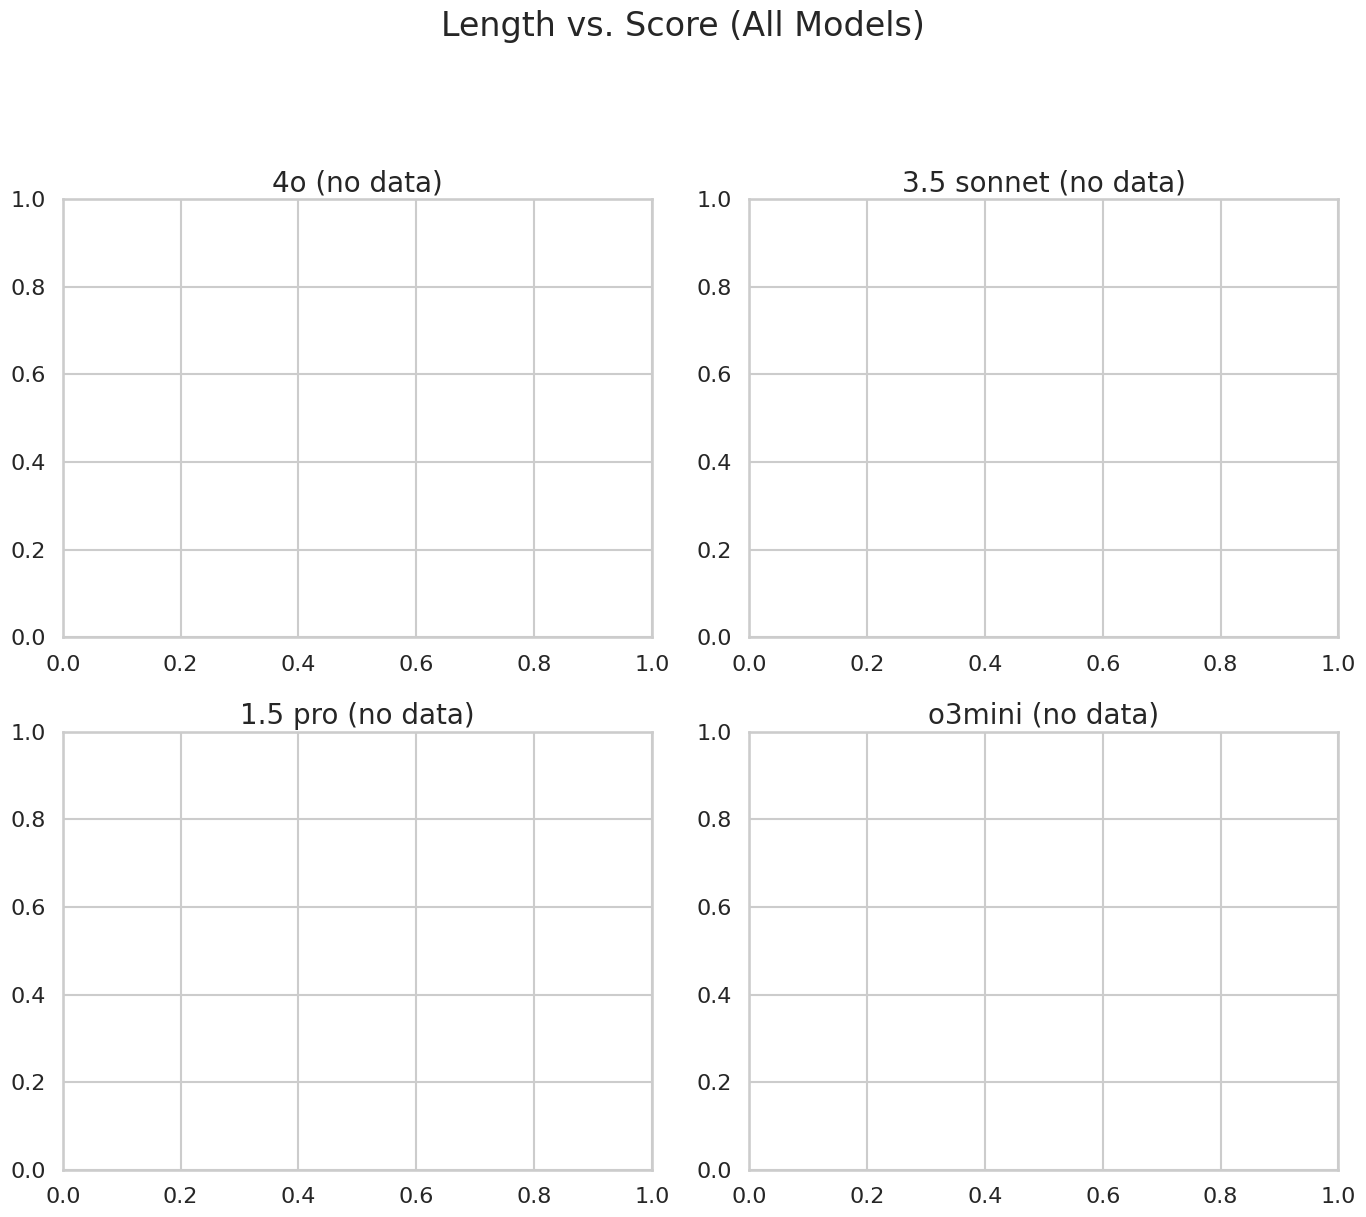

In [ ]:
import os
import pickle
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from tqdm.notebook import tqdm
from scipy.stats import spearmanr  # Import Spearman rank correlation

# Mount Google Drive
drive.mount('/content/drive')

# Set a seaborn style for an aesthetically pleasing look.
sns.set(style="whitegrid", context="talk")

# Define base directory where your research paper data is stored.
base_dir = '/content/drive/MyDrive/ResearchPapers'

# Mapping for each LLM with:
#   - its predictions pickle file (each a list of JSON-formatted texts)
#   - its corresponding judging directory
model_info = {
    "4o": {
        "predictions_file": os.path.join(base_dir, "official_gpt_predictions", "predictions.pkl"),
        "judging_dir": os.path.join(base_dir, "4o_judging")
    },
    "3.5 sonnet": {
        "predictions_file": os.path.join(base_dir, "official_claude_predictions", "predictions.pkl"),
        "judging_dir": os.path.join(base_dir, "claude_judging")
    },
    "1.5 pro": {
        "predictions_file": os.path.join(base_dir, "gemini_official_predictions", "predictions.pkl"),
        "judging_dir": os.path.join(base_dir, "gemini_judging")
    },
    "o3mini": {
        "predictions_file": os.path.join(base_dir, "o3mini_official_predictions", "predictions.pkl"),
        "judging_dir": os.path.join(base_dir, "o3mini_judging")
    },
}

# Define allowed judge file names.
allowed_judge_files = {
    "claude_35sonnet_majority_judge.txt",
    # "gemini_15pro_majority_judge.txt",
    "o3_mini_majority_judge.txt",
    "grok_2_majority_judge.txt",
    "gpt_4o_majority_judge.txt",
}

# Map each model to its corresponding judge file (to exclude its own judge)
model_to_judge_file = {
    "4o": "gpt_4o_majority_judge.txt",
    "3.5 sonnet": "claude_35sonnet_majority_judge.txt",
    "1.5 pro": "gemini_15pro_majority_judge.txt",
    "o3mini": "o3_mini_majority_judge.txt",
}

# Container for storing data (one DataFrame per model)
data_dict = {}

# Loop over each model with a progress bar
for model, info in tqdm(model_info.items(), desc="Processing Models"):
    # Load the predictions (each predictions.pkl is a list of JSON-formatted texts)
    with open(info["predictions_file"], "rb") as f:
        predictions = pickle.load(f)

    records = []

    # We assume the order of predictions corresponds to paper IDs: paper_000, paper_001, etc.
    for idx, pred_entry in enumerate(tqdm(predictions, desc=f"{model} predictions", leave=False)):
        paper_id = f"paper_{idx:03d}"  # e.g. "paper_000"

        # Ensure pred_entry is a dictionary (if it's a string, parse it)
        if isinstance(pred_entry, str):
            try:
                pred_data = json.loads(pred_entry)
            except Exception as e:
                print(f"Error parsing JSON for {paper_id}: {e}")
                continue
        else:
            pred_data = pred_entry

        # Get the methodology field (originally contributions) and compute its word count.
        # Note: the key remains 'contributions' in the code logic.
        contributions = pred_data.get("contributions", [])
        total_length = len(str(contributions).split())

        # Locate the corresponding judging folder for this paper.
        paper_judging_folder = os.path.join(info["judging_dir"], paper_id)
        if not os.path.isdir(paper_judging_folder):
            print(f"Warning: Judging folder for paper {paper_id} not found in {info['judging_dir']}. Skipping.")
            continue

        # Load all judging files (each file is JSON with keys "explanation" and "score").
        judge_files = glob.glob(os.path.join(paper_judging_folder, "*.txt"))
        judge_scores = []
        for jf in tqdm(judge_files, desc=f"{paper_id} judge files", leave=False):
            filename = os.path.basename(jf)

            # Filter: only include allowed judge files.
            if filename not in allowed_judge_files:
                continue

            # Exclude the judge file corresponding to the current model.
            if filename == model_to_judge_file.get(model, ""):
                continue

            try:
                with open(jf, "r") as f_judge:
                    judge_data = json.load(f_judge)
                score = judge_data.get("score", None)
                if score is not None:
                    judge_scores.append(score)
            except Exception as e:
                print(f"Error reading {jf}: {e}")

        # Compute the aggregated (mean) judge score if any scores were found.
        # If none are found, we'll temporarily set it to NaN for imputation later.
        mean_score = np.mean(judge_scores) if judge_scores else np.nan

        records.append({
            "paper_id": paper_id,
            "total_length": total_length,
            "mean_score": mean_score
        })

    # Save the data for this model into a DataFrame.
    df = pd.DataFrame(records)
    # Impute missing judge scores using the median of the available scores for the model.
    median_score = df["mean_score"].median()
    if pd.isna(median_score):
        median_score = 0
    df["mean_score"] = df["mean_score"].fillna(median_score)

    data_dict[model] = df

# Create a 2x2 grid of plots—one subplot per model.
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (model, df) in zip(axes, data_dict.items()):
    # Plot the relationship between methodology length and aggregated judge score using a scatter plot.
    sns.regplot(
        x="total_length",
        y="mean_score",
        data=df,
        ax=ax,
        scatter_kws={"s": 50, "alpha": 0.7},
        fit_reg=True  # Remove regression line
    )

    # Calculate Spearman rank correlation coefficient and p-value.
    rho, p_val = spearmanr(df["total_length"], df["mean_score"])

    # Annotate the plot with Spearman correlation results (optional).
    # ax.annotate(f"Spearman rho: {rho:.2f}\np-value: {p_val:.3f}",
    #             xy=(0.05, 0.95), xycoords="axes fraction",
    #             fontsize=12, verticalalignment="top",
    #             bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

    ax.set_title(f"{model}: Methodology Length vs. Judge Score", fontsize=16)
    ax.set_xlabel("Methodology Length (word count)", fontsize=14)
    ax.set_ylabel("Mean Judge Score", fontsize=14)

# Set an overall title for the figure.
plt.suptitle("Relationship between Methodology Length and Judge Score\n(with imputed values for missing scores)", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Processing: 4o_judging (excluding judge: gpt_4o)


Loaded 264 entries from 4o_judging.
Mean scores saved to /content/drive/MyDrive/ResearchPapers/4o_judging/4o_judging_new_mean_scores.csv

Processing: o3mini_judging (excluding judge: o3_mini)


Loaded 264 entries from o3mini_judging.
Mean scores saved to /content/drive/MyDrive/ResearchPapers/o3mini_judging/o3mini_judging_new_mean_scores.csv

Processing: claude_judging (excluding judge: claude_35sonnet)


Loaded 264 entries from claude_judging.
Mean scores saved to /content/drive/MyDrive/ResearchPapers/claude_judging/claude_judging_new_mean_scores.csv

Processing: gemini_judging (excluding judge: gemini_15pro)


Loaded 352 entries from gemini_judging.
Mean scores saved to /content/drive/MyDrive/ResearchPapers/gemini_judging/gemini_judging_new_mean_scores.csv


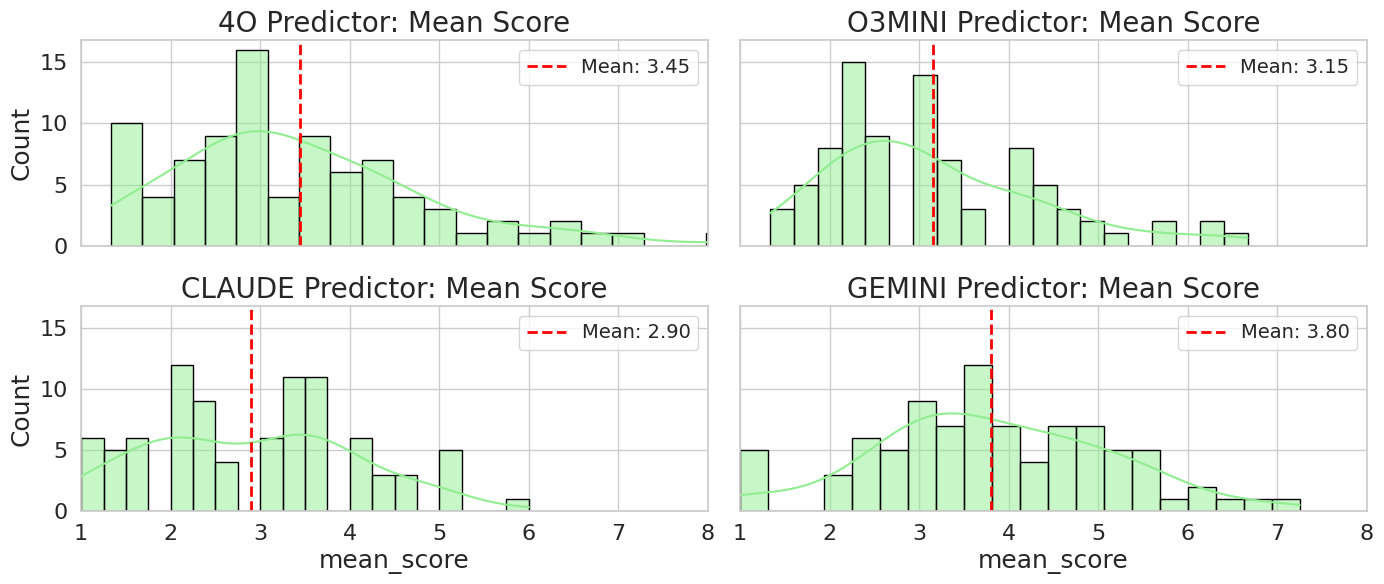

Combined histogram panel saved to /content/drive/MyDrive/ResearchPapers/new_new_combined_mean_score_distributions.png


In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from google.colab import drive

# Mount Google Drive (Colab-specific)
drive.mount('/content/drive')

# -------------------------------
# Global Style Settings for Bigger Text
# -------------------------------
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    'figure.autolayout': True,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16
})

# -------------------------------
# Define Parent Directory and Allowed Judge Models
# -------------------------------
ROOT_DIR = '/content/drive/MyDrive/ResearchPapers'

allowed_judges = {"claude_35sonnet", "gpt_4o", "grok_2", "o3_mini"}
base_exclude_map = {
    "4o": "gpt_4o",
    "claude": "claude_35sonnet",
    "gemini": "gemini_15pro",
    "o3mini": "o3_mini"
}

# ----------------------------------------------------------------
# List the base directories (predictors) you want to plot together
# Adjust these to match the actual folder names in your environment
# ----------------------------------------------------------------
base_dirs = [
    "4o_judging",       # e.g. GPT-4
    "o3mini_judging",   # e.g. O3 Mini
    "claude_judging",   # e.g. Claude
    "gemini_judging"    # e.g. Gemini
]

# Create a 2x2 figure with shared x- and y-axes, but with a reduced height (less tall histograms)
fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True, sharey=True)
axes = axes.flatten()

for idx, base_dir in enumerate(base_dirs):
    base_dir_path = os.path.join(ROOT_DIR, base_dir)
    if not os.path.isdir(base_dir_path):
        print(f"Skipping {base_dir_path}, not a directory.")
        continue

    # Derive base_key (e.g., "4o") from the directory name
    base_key = base_dir.replace("_judging", "")
    exclude_model = base_exclude_map.get(base_key, None)

    # Determine which judges are allowed for this base directory
    allowed_for_this_base = allowed_judges.copy()
    if exclude_model and exclude_model in allowed_for_this_base:
        allowed_for_this_base.remove(exclude_model)

    print(f"\nProcessing: {base_dir} (excluding judge: {exclude_model})")
    records = []

    to_remove = ["paper_000", "paper_001", "paper_003", "paper_025", "paper_029", "paper_036", "paper_043", "paper_050", "paper_055", "paper_060", "paper_076", "paper_081", "paper_097"]

    # Loop over each paper folder
    for paper in tqdm(sorted(os.listdir(base_dir_path)), desc=f"Processing papers in {base_dir}", leave=False):

        if paper in to_remove:
            continue

        paper_dir = os.path.join(base_dir_path, paper)
        if not os.path.isdir(paper_dir):
            continue

        # Loop over each judging file
        for file in sorted(os.listdir(paper_dir)):
            if file.endswith('_majority_judge.txt'):
                model = file.replace('_majority_judge.txt', '')
                if model not in allowed_for_this_base:
                    continue

                file_path = os.path.join(paper_dir, file)
                try:
                    with open(file_path, 'r') as f:
                        data = json.load(f)
                except json.JSONDecodeError:
                    print(f"Error decoding JSON in file: {file_path}")
                    continue

                score = data.get('score')
                records.append({'paper': paper, 'model': model, 'score': score})

    # Convert records to DataFrame
    df = pd.DataFrame(records)
    print(f"Loaded {len(df)} entries from {base_dir}.")

    if df.empty:
        # Skip if no data
        continue

    # Pivot to get columns for each model's score
    df_scores = df.pivot(index='paper', columns='model', values='score').reset_index()

    # Compute mean score across allowed judges
    def compute_mean(row):
        vals = [
            row[m] for m in allowed_for_this_base
            if m in row and pd.notnull(row[m])
        ]
        return sum(vals) / len(vals) if vals else None

    df_scores['mean_score'] = df_scores.apply(compute_mean, axis=1)

    # Optional: save the mean scores CSV (if desired)
    csv_output_path = os.path.join(base_dir_path, f"{base_dir}_new_mean_scores.csv")
    df_scores.to_csv(csv_output_path, index=False)
    print(f"Mean scores saved to {csv_output_path}")

    # -------------------------------
    # Plot on the corresponding subplot
    # -------------------------------
    ax = axes[idx]
    sns.histplot(
        df_scores['mean_score'],
        kde=True,
        bins=20,
        color="lightgreen",
        edgecolor="black",
        ax=ax
    )
    overall_mean = df_scores['mean_score'].mean()
    ax.axvline(overall_mean, color='red', linestyle='--', lw=2, label=f"Mean: {overall_mean:.2f}")
    ax.set_title(f"{base_key.upper()} Predictor: Mean Score", fontsize=20)
    ax.legend(fontsize=14)

# -------------------------------
# Force a fixed x-axis range for all subplots
# (adjust as needed for your data)
# -------------------------------
for ax in axes:
    ax.set_xlim(1, 8)
    # Optionally fix the y-axis if you know a max frequency
    # ax.set_ylim(0, 30)

plt.tight_layout()

# Save a single PNG of the 2x2 panel
panel_output_path = os.path.join(ROOT_DIR, "new_combined_mean_score_distributions.png")
plt.savefig(panel_output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Combined histogram panel saved to {panel_output_path}")


In [ ]:
from google.colab import drive, userdata
import pickle
import json
import os
import textwrap
from openai import OpenAI
from pydantic import BaseModel, Field
drive.mount('/content/drive')

summarize_original = """
You will be given parts of a research paper in JSON format.

Instructions:
- You are an expert researcher.
- You will summarize the given research paper.

Output Format:
- Provide your response in valid JSON format with the following keys
- proposed_method: str (Using the given information, first summarize the inspiration behind the proposed method to address the main research problem. Summarize the motivation for why the proposed method would work better than existing works. Then, summarize how the proposed approach works, and describe all the essential steps.)
- experimental_plan: str (Break down EVERY single step in proposed_method. Every step MUST be executable. Cover ALL essential details such as the datasets, models, and metrics to be used, etc.)
"""

class Outline(BaseModel):
    proposed_method: str = Field(..., description="""Using the given information, first summarize the inspiration behind the proposed method to address the main research problem. Summarize the motivation for why the proposed method would work better than existing works. Then, summarize how the proposed approach works, and describe all the essential steps.""")
    experimental_plan: str = Field(..., description="""Break down EVERY single step in 'proposed_method'. Every step MUST be executable. Cover ALL essential details such as the datasets, models, metrics to be used, etc.""")

client = OpenAI(api_key = userdata.get("openai"))

def api_call(prompt, inputs, format, parsed, temperature=0.0):
    messages = [{"role": "system", "content": prompt}]
    for user_input in inputs:
        messages.append({"role": "user", "content": user_input})

    completions = client.beta.chat.completions.parse(
        model="gpt-4o",
        messages=messages,
        response_format=format,
        temperature=temperature
    )

    if parsed:
        return completions.choices[0].message.parsed
    else:
        return completions.choices[0].message.content

def outline(redacted_paper):
    return api_call(summarize_original, [redacted_paper], Outline, True, 0.8)

def process_text(text, width=120):
    """
    Remove all newline characters from the input text and then wrap the text to a maximum width.

    Parameters:
        text (str): The input text.
        width (int): Maximum number of characters per line.

    Returns:
        str: The processed text with newlines inserted at the specified width.
    """
    # Remove all explicit newline characters
    text_no_newlines = text.replace('\\n', ' ')
    # Wrap the text to the given width
    # wrapped_text = textwrap.fill(text_no_newlines, width=width)
    return text_no_newlines

idx = 39

ground_truths = pickle.load(open('/content/drive/MyDrive/ResearchPapers/ground_truth.pkl', 'rb'))
gpt_predictions = pickle.load(open('/content/drive/MyDrive/ResearchPapers/official_gpt_predictions/predictions.pkl', 'rb'))
gpt_outlines = pickle.load(open('/content/drive/MyDrive/ResearchPapers/official_gpt_predictions/outline_list.pkl', 'rb'))

print(process_text(outline(str(json.loads(ground_truths[idx])['contributions'])).experimental_plan))
print(process_text(json.loads(gpt_outlines[idx])['experimental_plan']))
# json.loads(ground_truths[0])['contributions']
# process_text(str(json.loads(gpt_predictions[0])['contributions']))